Clean, working synthetic control script for migration flows.

Key fixes vs your draft
- Consistent variable names and structure
- No duplicate blocks; factored helpers for fitting/diagnostics/placebos
- Group-weight constraints (>= 0.4 for origin and destination groups) are
  applied ONLY to the two combined models:
    1) Combined donors
    2) Combined donors with JM->US left out
  They are NOT applied to origin-only or destination-only fits
- Safer solver logic (OSQP, fallback to SCS), better checks, clearer prints

What you need to set
- CSV_PATH points to your `international_migration_flow.csv`
- Confirm the column names match exactly: 
  ['migration_month','country_from','country_to','num_migrants']

Tested with pandas 2.x, numpy 1.26+, cvxpy 1.4+, matplotlib 3.8+

In [1]:
from __future__ import annotations
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import cvxpy as cp
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import linregress
import statsmodels.api as sm

In [2]:
# ----------------------------- Utilities -----------------------------
@dataclass
class FitResult:
    synth: np.ndarray
    weights: np.ndarray
    status: str


def require_columns(df: pd.DataFrame, cols: list[str]):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in CSV: {missing}")


def load_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    require_columns(df, ["migration_month", "country_from", "country_to", "num_migrants"])

    df = df.copy()
    df["migration_month"] = pd.to_datetime(df["migration_month"])
    df["year"] = df["migration_month"].dt.year
    df["month"] = df["migration_month"].dt.month
    df["country_to"] = df["country_to"].astype(str)
    df["country_from"] = df["country_from"].astype(str)
    return df


def pick_similar_donors(df: pd.DataFrame,
                        treated_from: str,
                        treated_to: str,
                        exclude_origins: list[str],
                        top_k: int) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    """Return monthly rows for two donor sets and the treated total (levels).
    - same-origin (treated_from -> other destinations)
    - same-destination (other origins -> treated_to)
    """
    totals = df.groupby(["country_from", "country_to"], as_index=False)["num_migrants"].sum()

    # treated total (levels)
    treated_total = (
        totals.loc[(totals["country_from"] == treated_from) &
                   (totals["country_to"] == treated_to), "num_migrants"]
        .iloc[0]
    )

    # same-origin donors: treated_from -> other destinations (exclude treated_to)
    same_origin_total = totals[(totals["country_from"] == treated_from) &
                               (totals["country_to"] != treated_to)]
    same_origin_top = same_origin_total.iloc[(same_origin_total["num_migrants"] - treated_total)
                                             .abs().argsort()[:top_k]]
    same_origin_dests = same_origin_top["country_to"].unique()
    same_origin_monthly = df[(df["country_from"] == treated_from) &
                             (df["country_to"].isin(same_origin_dests))]

    # same-destination donors: other origins -> treated_to
    same_dest_total = totals[(totals["country_to"] == treated_to)]
    same_dest_total = same_dest_total[~same_dest_total["country_from"].isin(exclude_origins + [treated_from])]
    same_dest_total = same_dest_total[(same_dest_total["country_from"] != treated_from) |
                                      (same_dest_total["country_to"] != treated_to)]
    same_dest_top = same_dest_total.iloc[(same_dest_total["num_migrants"] - treated_total)
                                         .abs().argsort()[:top_k]]
    same_dest_origins = same_dest_top["country_from"].unique()
    same_dest_monthly = df[(df["country_to"] == treated_to) &
                           (df["country_from"].isin(same_dest_origins))]

    return same_origin_monthly.copy(), same_dest_monthly.copy(), float(treated_total)


def make_panel(df_control: pd.DataFrame) -> pd.DataFrame:
    dfc = df_control.copy()
    dfc["unit"] = dfc["country_from"] + "->" + dfc["country_to"]
    dfc["month"] = dfc["migration_month"].dt.to_period("M").dt.to_timestamp()
    panel = (dfc.pivot_table(index="month", columns="unit", values="num_migrants", aggfunc="sum")
                 .sort_index())

    # Fill missing months
    all_months = pd.date_range(panel.index.min(), panel.index.max(), freq="MS")
    panel = panel.reindex(all_months)
    if FILL_METHOD == "zero":
        panel = panel.fillna(0)
    else:  # interpolate (both ways)
        panel = panel.interpolate(limit_direction="both")
    return panel


def to_modelling_scale(values: np.ndarray, use_log: bool) -> np.ndarray:
    return np.log1p(values) if use_log else values.astype(float)


def to_level_scale(values: np.ndarray, use_log: bool) -> np.ndarray:
    return np.expm1(values) if use_log else values.astype(float)


def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)


def label_slug(*parts: str) -> str:
    # build filesystem-friendly slug
    txt = "_".join([s for s in parts if s])
    return txt.replace(" ", "-").replace(".", "p").replace(":", "-")


def savefig(path: Path):
    if SAVE_FIGS:
        plt.savefig(path, dpi=200, bbox_inches='tight')


def fit_synth(y_target: np.ndarray,
              Y_pool: np.ndarray,
              pre_mask: np.ndarray,
              group_indices: dict[str, list[int]] | None = None,
              min_group_share: float | None = None,
              weight_cap: float | None = None,
              solver: str = "OSQP") -> FitResult:
    """Fit nonnegative weights summing to 1; optional group-share lower bounds and per-donor cap.
    group_indices: {"origin": [idx...], "destination": [idx...]}
    """
    T, J = Y_pool.shape
    if J < 1:
        raise ValueError("No donors in Y_pool")

    w = cp.Variable(J, nonneg=True)
    constraints = [cp.sum(w) == 1]

    # Per-donor cap if requested
    if weight_cap is not None and weight_cap < 1.0:
        constraints.append(w <= weight_cap)

    # Add group-share >= min_group_share if requested and groups exist
    if min_group_share is not None and group_indices:
        for gname, idxs in group_indices.items():
            if idxs and 0 < min_group_share < 1:
                constraints.append(cp.sum(cp.hstack([w[i] for i in idxs])) >= min_group_share)

    resid_pre = Y_pool[pre_mask, :] @ w - y_target[pre_mask]
    prob = cp.Problem(cp.Minimize(cp.sum_squares(resid_pre)), constraints)

    status = "unsolved"
    try:
        prob.solve(solver=solver, warm_start=True, verbose=False)
        status = prob.status
    except Exception:
        # Fallback solver
        try:
            prob.solve(solver="SCS", warm_start=True, verbose=False)
            status = prob.status
        except Exception:
            status = "failed"

    w_opt = np.maximum(np.array(w.value).flatten(), 0.0) if w.value is not None else np.zeros(J)
    if w_opt.sum() > 0:
        w_opt /= w_opt.sum()

    synth = Y_pool.dot(w_opt)
    return FitResult(synth=synth, weights=w_opt, status=status)


def diagnostics(y_target: np.ndarray,
                synth: np.ndarray,
                pre_mask: np.ndarray,
                post_mask: np.ndarray,
                use_log: bool) -> dict:
    # Work on modelling scale for RMSPE/MSPE
    pre_err = y_target[pre_mask] - synth[pre_mask]
    post_err = y_target[post_mask] - synth[post_mask]
    pre_mspe = float(np.mean(pre_err ** 2)) if pre_mask.any() else np.nan
    post_mspe = float(np.mean(post_err ** 2)) if post_mask.any() else np.nan
    res = {
        "pre_rmspe": float(np.sqrt(pre_mspe)) if np.isfinite(pre_mspe) else np.nan,
        "post_rmspe": float(np.sqrt(post_mspe)) if np.isfinite(post_mspe) else np.nan,
        "mspe_ratio": float(post_mspe / (pre_mspe + 1e-12)) if np.isfinite(pre_mspe) else np.nan,
    }

    # ATT in levels
    treated_levels = to_level_scale(y_target, use_log)
    synth_levels = to_level_scale(synth, use_log)
    cum_att = float(treated_levels[post_mask].sum() - synth_levels[post_mask].sum())
    synth_post_sum = float(synth_levels[post_mask].sum())
    res.update({
        "cum_att_levels": cum_att,
        "pct_change_post": float(cum_att / (synth_post_sum + 1e-12)) if synth_post_sum != 0 else np.nan,
    })
    return res


def pre_fit_validity_metrics(y_target: np.ndarray, synth: np.ndarray, pre_mask: np.ndarray, use_log: bool) -> dict:
    """Return R^2, correlation, MAPE in levels, and a pre-trend test for the pre-period."""
    y_pre = y_target[pre_mask]
    s_pre = synth[pre_mask]
    if y_pre.size == 0:
        return {k: np.nan for k in ["pre_r2","pre_corr","pre_mape","pre_gap_slope","pre_gap_trend_p"]}

    # R^2 and correlation (modelling scale)
    ss_res = float(np.sum((y_pre - s_pre)**2))
    ss_tot = float(np.sum((y_pre - np.mean(y_pre))**2))
    r2 = 1.0 - ss_res/(ss_tot + 1e-12)
    corr = float(np.corrcoef(y_pre, s_pre)[0, 1]) if y_pre.size > 1 else np.nan

    # MAPE in *levels* (robust to log usage)
    yL = to_level_scale(y_pre, use_log)
    sL = to_level_scale(s_pre, use_log)
    mape = float(np.mean(np.abs((yL - sL) / (yL + 1e-12)))) if yL.size > 0 else np.nan

    # Pre-trend test on the gap (slope ~ 0 under good pre-fit)
    gap_pre = (y_pre - s_pre)
    if gap_pre.size > 1:
        x = np.arange(gap_pre.size)
        lr = linregress(x, gap_pre)
        slope = float(lr.slope)
        pval = float(lr.pvalue)
    else:
        slope = np.nan
        pval = np.nan

    return {"pre_r2": r2, "pre_corr": corr, "pre_mape": mape, "pre_gap_slope": slope, "pre_gap_trend_p": pval}


def unit_placebo_gaps(y_target: np.ndarray, donor_df: pd.DataFrame, pre_mask: np.ndarray) -> dict:
    """For each donor treated as pseudo-treated, return its full-period gap series (modelling scale)."""
    gaps = {}
    cols = list(donor_df.columns)
    for c in cols:
        others = [x for x in cols if x != c]
        if len(others) < 3:
            continue
        y_p = donor_df[c].values
        fr_p = fit_synth(y_p, donor_df[others].values, pre_mask)
        gaps[c] = y_p - fr_p.synth
    return gaps


def plot_pre_fit_scatter(dates: pd.DatetimeIndex, y_pre: np.ndarray, s_pre: np.ndarray, use_log: bool, title: str = "Pre-period fit (levels)"):
    yL = to_level_scale(y_pre, use_log)
    sL = to_level_scale(s_pre, use_log)
    plt.figure(figsize=(6, 6))
    plt.scatter(yL, sL, alpha=0.7)
    maxv = float(np.nanmax([yL.max(), sL.max()])) if yL.size and sL.size else 1.0
    plt.plot([0, maxv], [0, maxv], linestyle='--')
    plt.xlabel('Treated (levels)')
    plt.ylabel('Synthetic (levels)')
    plt.title(title)
    plt.tight_layout(); plt.show()


def plot_placebo_gaps(dates: pd.DatetimeIndex, treated_gap: np.ndarray, placebo_gaps: dict, treatment_idx: int, title: str):
    plt.figure(figsize=(12, 5))
    for g in placebo_gaps.values():
        plt.plot(dates, g, linewidth=0.8, alpha=0.35)
    plt.plot(dates, treated_gap, linewidth=2.0, label='Treated gap',)
    plt.axvline(dates[treatment_idx], color='k', linestyle=':')
    plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
    plt.legend(); plt.title(title)
    plt.tight_layout(); plt.show()


def unit_placebos(y_target: np.ndarray, donor_df: pd.DataFrame,
                  pre_mask: np.ndarray, post_mask: np.ndarray) -> tuple[float, dict, float, int]:
    """Run donor-level (unit) placebos, return treated ratio, dict of placebo ratios, p-value, N."""
    # treated fit (no group constraints for placebos)
    fr = fit_synth(y_target, donor_df.values, pre_mask)
    treated_ratio = diagnostics(y_target, fr.synth, pre_mask, post_mask, use_log=False)["mspe_ratio"]

    ratios = {}
    cols = list(donor_df.columns)
    for c in cols:
        others = [x for x in cols if x != c]
        if len(others) < 3:
            continue
        y_p = donor_df[c].values
        fr_p = fit_synth(y_p, donor_df[others].values, pre_mask)
        ratios[c] = diagnostics(y_p, fr_p.synth, pre_mask, post_mask, use_log=False)["mspe_ratio"]

    vals = np.array(list(ratios.values()))
    if vals.size == 0:
        pval, n = np.nan, 0
    else:
        n = vals.size
        pval = (np.sum(vals >= treated_ratio) + 1) / (n + 1)
    return float(treated_ratio), ratios, float(pval), int(n)


def month_placebos(y_target: np.ndarray, donor_df: pd.DataFrame,
                   time_index: pd.DatetimeIndex, treatment_date: pd.Timestamp,
                   use_log: bool, n_months: int) -> pd.DataFrame:
    """Run month-placebos using last n pre-treatment months; keep post window length fixed."""
    results = []
    orig_post_mask = (time_index >= treatment_date)
    T_post = int(orig_post_mask.sum())
    pre_months = time_index[time_index < treatment_date]
    candidates = list(pre_months[-n_months:])

    for pm in tqdm(candidates, desc="month-placebos"):
        pre_mask = (time_index < pm)
        post_end = pd.Timestamp(pm) + pd.DateOffset(months=T_post)
        post_mask = (time_index >= pm) & (time_index < post_end)

        if pre_mask.sum() < max(MIN_PRE_MONTHS, 6) or post_mask.sum() == 0:
            results.append({"placebo_date": pm, "status": "insufficient_pre_or_post"})
            continue

        fr = fit_synth(y_target, donor_df.values, pre_mask)
        d = diagnostics(y_target, fr.synth, pre_mask, post_mask, use_log)
        results.append({
            "placebo_date": pm,
            "status": fr.status,
            "pre_rmspe": d["pre_rmspe"],
            "post_rmspe": d["post_rmspe"],
            "mspe_ratio": d["mspe_ratio"],
            "cum_att_levels": d["cum_att_levels"],
            "pct_change_post": d["pct_change_post"],
        })

    out = pd.DataFrame(results).sort_values("placebo_date").reset_index(drop=True)
    if not out.empty and "placebo_date" in out:
        out["placebo_date_str"] = out["placebo_date"].dt.strftime("%Y-%m-%d")
    return out

In [29]:
# ----------------------------- Configuration -----------------------------
CSV_PATH = Path("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Oxford/Migration/international_migration_flow.csv")

# TREATED_FROM = "CL"
# TREATED_TO = "US"
# TREATMENT_DATE = pd.Timestamp("2021-01-01")
# EXCLUDE_ORIGINS = ["RU", "UA", "AF", "HT"]  # excluded from any->US search

TREATED_FROM = "TR"
TREATED_TO = "DE"
TREATMENT_DATE = pd.Timestamp("2021-09-01")
# TREATMENT_DATE = pd.Timestamp("2022-06-01")
# EXCLUDE_ORIGINS = ["PL", "IN"]  


# Donor selection & modelling
TOP_K = 10                                        # how many similar flows to use per side
USE_LOG = True                                    # default modelling scale (can be overridden by RUN_BOTH_LOG_SPECS)
MIN_PRE_MONTHS = 12                               # minimum pre months required

# Group-share constraints (only for combined models)
MIN_GROUP_SHARE = 0.40  # each of origin & destination groups >= 0.40 (if present)

# Sensitivity toggles
RUN_BOTH_LOG_SPECS = True                 # run both log1p and raw-count specs
RUN_SENSITIVITY_CONSTRAINTS = True        # run combined models at multiple group thresholds
CONSTRAINT_LEVELS = [0.30, 0.40, 0.50]
RUN_WEIGHT_CAP_VARIANT = True             # run combined with a per-donor cap in addition
WEIGHT_CAP = 0.50                         # max weight per single donor (only for combined models when enabled)
PLACEBOS_FOR_ALL_SPECS = False            # if False, run month-placebos only for the first (baseline) spec

# Optional leave-one-out donor behavior now automatic (we remove top-weight donor)

# Interpolation for missing months in panel: "interpolate" | "zero"
FILL_METHOD = "interpolate"

# Month-placebo settings
RUN_MONTH_PLACEBOS = True
N_PLACEBO_MONTHS = 12  # try the last N pre-treatment months as placebo dates

# Export settings
OUTPUT_DIR = Path("results")
SAVE_FIGS = True
SAVE_TABLES = True

In [30]:
RUN_BOTH_LOG_SPECS = False
USE_LOG = True               # main result is log
RUN_SENSITIVITY_CONSTRAINTS = False
CONSTRAINT_LEVELS = [0.40]   # ignored when flag above is False
RUN_WEIGHT_CAP_VARIANT = False
RUN_MONTH_PLACEBOS = True    # keep for timing placebo
PLACEBOS_FOR_ALL_SPECS = False

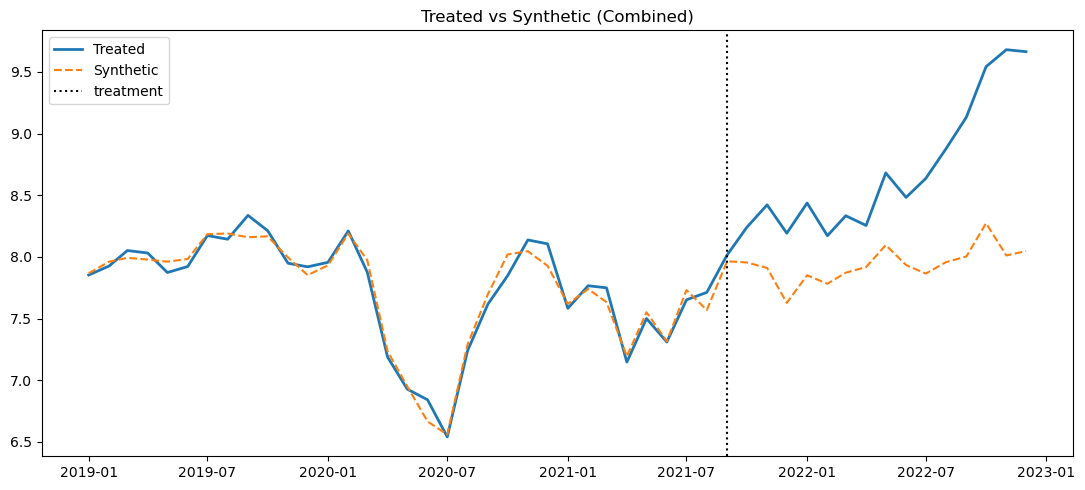

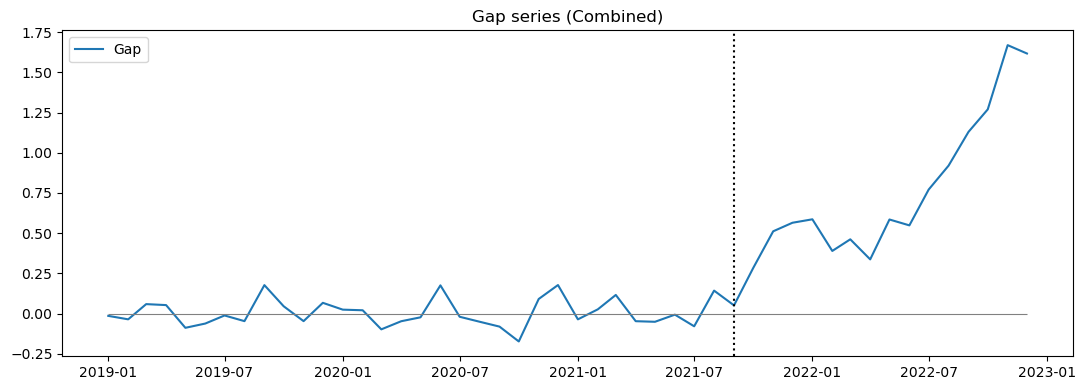

Pre-fit validity (Combined): {'pre_r2': 0.9612, 'pre_corr': 0.9805, 'pre_mape': 0.0676, 'pre_gap_slope': 0.0005, 'pre_gap_trend_p': 0.7594}


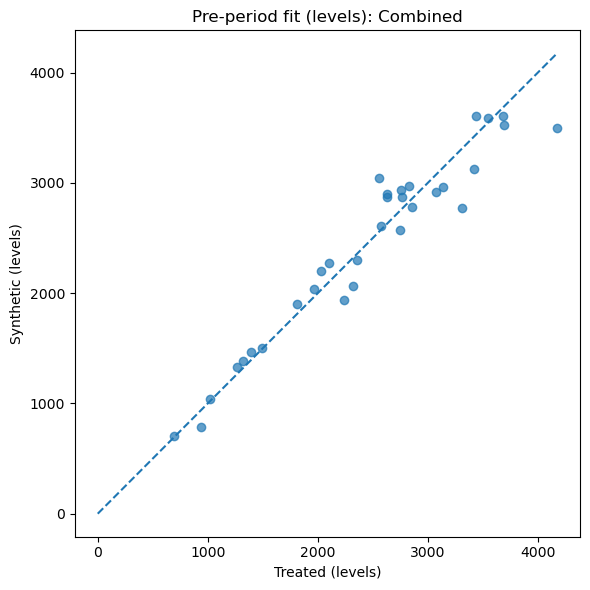

<Figure size 640x480 with 0 Axes>

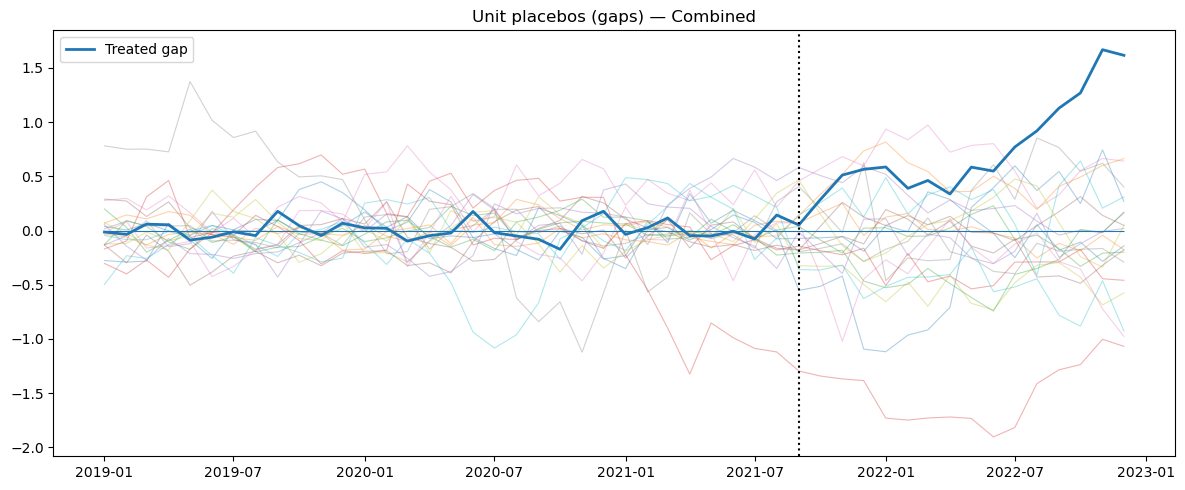

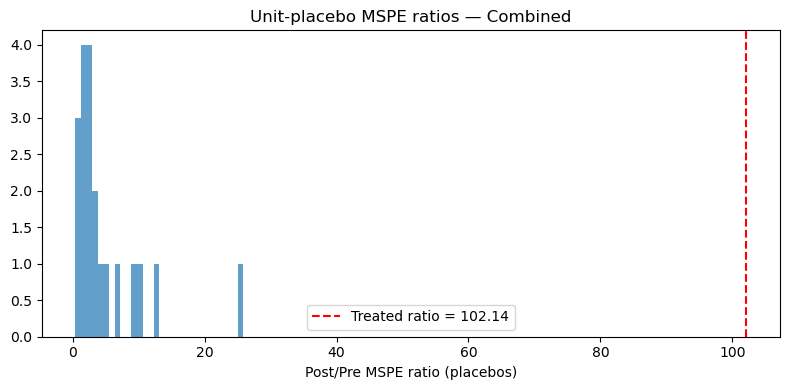

Share-of-US test: Post jump = 0.0143 (p=0.245), trend = 0.0005 (p=0.356)


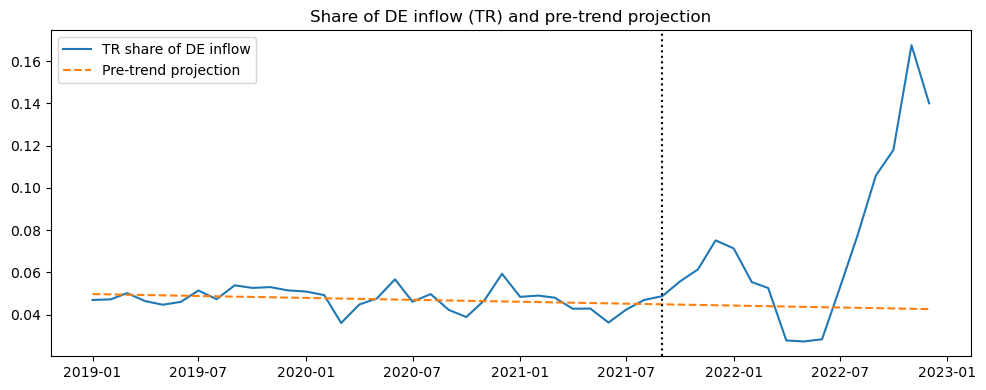

Average monthly post gap (levels): origin-only = 4381.9, destination-only = 4370.6


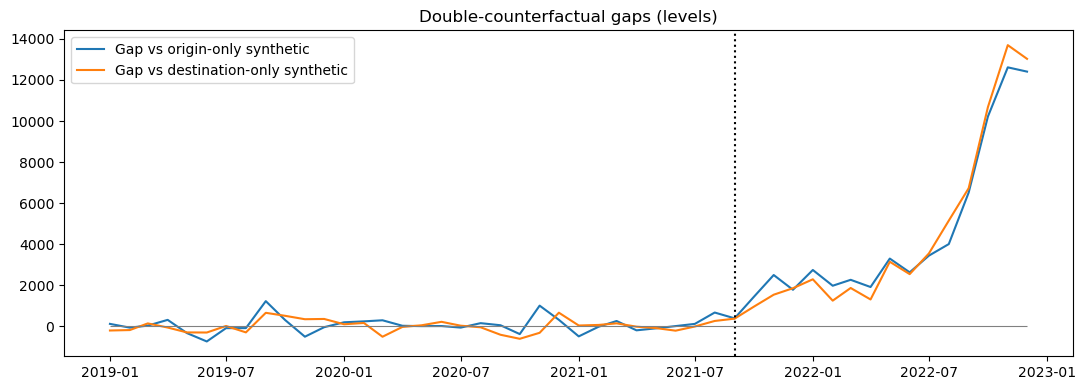

=== Synthetic Control Summary (spec) === scale=log; group>=0.4; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors      0.085       0.861               102.14                0.048          20               64200.90               141.32
                    Origin-only donors      0.143       0.961                45.15                0.091          10               70110.81               177.41
               Destination-only donors      0.114       1.010                78.29                0.091          10               69928.89               176.14
Combined (leave top donor out: RO->DE)      0.105       1.082               106.88                0.050          19               74508.77               212.15


month-placebos: 100%|██████████████████████████| 12/12 [00:00<00:00, 297.49it/s]


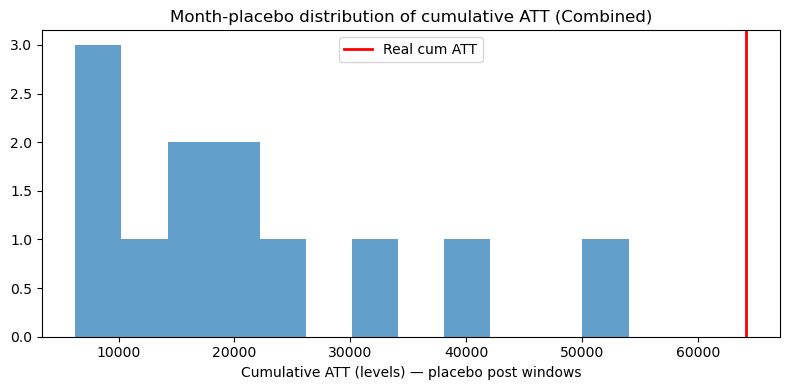

All scenarios completed. Results saved in: /Users/wenlanzhang/PycharmProjects/Mapineq/src/case_study/Migration/DID/results


In [31]:
# ----------------------------- Main Result -----------------------------

if __name__ == "__main__":
    # 1) Load
    df = load_data(CSV_PATH)

    # 2) Treated monthly rows and donor selection by similarity
    treat_df = df[(df["country_to"] == TREATED_TO) & (df["country_from"] == TREATED_FROM)].copy()
    if treat_df.empty:
        raise ValueError(f"Treated flow {TREATED_FROM}->{TREATED_TO} not found in data.")

    same_origin_m, same_dest_m, treated_total = pick_similar_donors(
        df, TREATED_FROM, TREATED_TO, EXCLUDE_ORIGINS, TOP_K
    )

    # 3) Control dataframe and panel (levels)
    df_control = pd.concat([treat_df, same_origin_m, same_dest_m], ignore_index=True)
    panel = make_panel(df_control)

    treated_unit = f"{TREATED_FROM}->{TREATED_TO}"
    if treated_unit not in panel.columns:
        raise ValueError(f"Treated unit {treated_unit} not in panel columns.")

    # Build donor labels from the *levels* panel
    donors_dest_labels = [c for c in panel.columns if c.endswith(f"->{TREATED_TO}") and c != treated_unit]
    donors_orig_labels = [c for c in panel.columns if c.startswith(f"{TREATED_FROM}->") and c != treated_unit]
    donors_combined_labels = donors_dest_labels + donors_orig_labels

    # Scenarios to run
    log_opts = [True, False] if RUN_BOTH_LOG_SPECS else [USE_LOG]
    constraint_opts = CONSTRAINT_LEVELS if RUN_SENSITIVITY_CONSTRAINTS else [MIN_GROUP_SHARE]

    scenarios = []
    for use_log in log_opts:
        for grp in constraint_opts:
            scenarios.append((use_log, grp, None, "base"))
            if RUN_WEIGHT_CAP_VARIANT:
                scenarios.append((use_log, grp, WEIGHT_CAP, "cap"))

    ensure_dir(OUTPUT_DIR)

    first_spec_done = False

    for (use_log, grp_share, weight_cap, tag) in scenarios:
        # 4) Build Y on chosen scale
        Y = panel.copy()
        if use_log:
            Y = pd.DataFrame(np.log1p(Y.values), index=Y.index, columns=Y.columns)

        # masks
        pre_mask = np.asarray(Y.index < TREATMENT_DATE, dtype=bool)
        post_mask = np.asarray(Y.index >= TREATMENT_DATE, dtype=bool)
        T_pre = int(pre_mask.sum())
        if T_pre < MIN_PRE_MONTHS:
            print(f"Warning: only {T_pre} pre months (< {MIN_PRE_MONTHS}). Results may be unstable.")

        # donor DataFrames
        donor_df_combined = Y[donors_combined_labels]
        donor_df_origin = Y[donors_orig_labels]
        donor_df_dest = Y[donors_dest_labels]

        # group index maps for combined
        orig_idx = [donors_combined_labels.index(d) for d in donors_orig_labels if d in donors_combined_labels]
        dest_idx = [donors_combined_labels.index(d) for d in donors_dest_labels if d in donors_combined_labels]
        group_map = {"origin": orig_idx, "destination": dest_idx}

        y_t = Y[treated_unit].values
        dates = Y.index
        treat_idx = int(pre_mask.sum())

        # 5) Fit models for this spec
        results = []
        weights_store = {}

        # Combined
        if donor_df_combined.shape[1] >= 1:
            fr_c = fit_synth(y_t, donor_df_combined.values, pre_mask,
                             group_indices=group_map, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_c = diagnostics(y_t, fr_c.synth, pre_mask, post_mask, use_log)
            tr_c, placebo_c, pval_c, n_c = unit_placebos(y_t, donor_df_combined, pre_mask, post_mask)
            results.append({
                "Model": "Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})",
                "Pre_RMSPE": d_c["pre_rmspe"],
                "Post_RMSPE": d_c["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_c["mspe_ratio"],
                "Permutation_p_value": pval_c,
                "N_placebos": n_c,
                "Cumulative_ATT_levels": d_c["cum_att_levels"],
                "Percent_change_post": d_c["pct_change_post"] * 100.0,
            })
            weights_store["Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})"] = pd.DataFrame({
                "donor": donors_combined_labels,
                "weight": fr_c.weights,
                "group": ["destination" if i in dest_idx else "origin" for i in range(len(donors_combined_labels))]
            }).sort_values("weight", ascending=False)

            # Plots & validity for combined
            plt.figure(figsize=(11, 5))
            plt.plot(dates, y_t, label="Treated", linewidth=2)
            plt.plot(dates, fr_c.synth, "--", label="Synthetic")
            plt.axvline(dates[treat_idx], color="k", linestyle=":", label="treatment")
            plt.title("Treated vs Synthetic (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("fit_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            plt.figure(figsize=(11, 4))
            plt.plot(dates, y_t - fr_c.synth, label="Gap")
            plt.axvline(dates[treat_idx], color="k", linestyle=":")
            plt.hlines(0, dates.min(), dates.max(), colors="gray", linewidth=0.8)
            plt.title("Gap series (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("gap_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            metrics = pre_fit_validity_metrics(y_t, fr_c.synth, pre_mask, use_log)
            print("Pre-fit validity (Combined):",
                  {k: (round(v, 4) if isinstance(v, float) and np.isfinite(v) else v) for k, v in metrics.items()})
            plot_pre_fit_scatter(dates, y_t[pre_mask], fr_c.synth[pre_mask], use_log,
                                 title="Pre-period fit (levels): Combined")
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("prefit_scatter_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
                plt.show()

            placebo_gaps_c = unit_placebo_gaps(y_t, donor_df_combined, pre_mask)
            if len(placebo_gaps_c) > 0:
                plt.figure(figsize=(12, 5))
                for g in placebo_gaps_c.values():
                    plt.plot(dates, g, linewidth=0.8, alpha=0.35)
                plt.plot(dates, y_t - fr_c.synth, linewidth=2.0, label='Treated gap')
                plt.axvline(dates[treat_idx], color='k', linestyle=':')
                plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
                plt.legend(); plt.title("Unit placebos (gaps) — Combined")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("unit_placebo_gaps", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                vals = np.array(list(placebo_c.values()))
                if vals.size > 0 and np.isfinite(tr_c):
                    plt.figure(figsize=(8, 4))
                    plt.hist(vals, bins=30, alpha=0.7)
                    plt.axvline(tr_c, color='red', linestyle='--', label=f"Treated ratio = {tr_c:.2f}")
                    plt.xlabel("Post/Pre MSPE ratio (placebos)"); plt.legend()
                    plt.title("Unit-placebo MSPE ratios — Combined")
                    plt.tight_layout()
                    if SAVE_FIGS:
                        figpath = OUTPUT_DIR / label_slug("unit_placebo_mspe_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                        savefig(figpath.with_suffix('.png'))
                    plt.show()

        # Origin-only (no group constraints, no cap)
        if donor_df_origin.shape[1] >= 1:
            fr_o = fit_synth(y_t, donor_df_origin.values, pre_mask)
            d_o = diagnostics(y_t, fr_o.synth, pre_mask, post_mask, use_log)
            tr_o, placebo_o, pval_o, n_o = unit_placebos(y_t, donor_df_origin, pre_mask, post_mask)
            results.append({
                "Model": "Origin-only donors",
                "Pre_RMSPE": d_o["pre_rmspe"],
                "Post_RMSPE": d_o["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_o["mspe_ratio"],
                "Permutation_p_value": pval_o,
                "N_placebos": n_o,
                "Cumulative_ATT_levels": d_o["cum_att_levels"],
                "Percent_change_post": d_o["pct_change_post"] * 100.0,
            })
            weights_store["Origin-only donors"] = pd.DataFrame({
                "donor": donors_orig_labels,
                "weight": fr_o.weights,
                "group": ["origin"] * len(donors_orig_labels)
            }).sort_values("weight", ascending=False)

        # Destination-only (no group constraints, no cap)
        if donor_df_dest.shape[1] >= 1:
            fr_d = fit_synth(y_t, donor_df_dest.values, pre_mask)
            d_d = diagnostics(y_t, fr_d.synth, pre_mask, post_mask, use_log)
            tr_d, placebo_d, pval_d, n_d = unit_placebos(y_t, donor_df_dest, pre_mask, post_mask)
            results.append({
                "Model": "Destination-only donors",
                "Pre_RMSPE": d_d["pre_rmspe"],
                "Post_RMSPE": d_d["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_d["mspe_ratio"],
                "Permutation_p_value": pval_d,
                "N_placebos": n_d,
                "Cumulative_ATT_levels": d_d["cum_att_levels"],
                "Percent_change_post": d_d["pct_change_post"] * 100.0,
            })
            weights_store["Destination-only donors"] = pd.DataFrame({
                "donor": donors_dest_labels,
                "weight": fr_d.weights,
                "group": ["destination"] * len(donors_dest_labels)
            }).sort_values("weight", ascending=False)
        # === Additional diagnostics for main spec only (share-of-US and double-gap) ===
        # Run only for the primary presentation spec to avoid spam: log scale, group>=0.40, no cap
        if use_log and abs(grp_share - 0.40) < 1e-9 and (weight_cap is None):
            # --- Share-of-US inflow test: CL->US share of total US inflow
            df_with_month = df.assign(month=pd.to_datetime(df['migration_month']).dt.to_period('M').dt.to_timestamp())
            us_total = (df_with_month[df_with_month['country_to'] == TREATED_TO]
                        .groupby('month', as_index=True)['num_migrants'].sum().to_frame('us_total'))
            cl_us = (df_with_month[(df_with_month['country_to'] == TREATED_TO) & (df_with_month['country_from'] == TREATED_FROM)]
                     .groupby('month', as_index=True)['num_migrants'].sum().to_frame('cl_us'))
            share = cl_us.join(us_total, how='outer').fillna(0.0)
            share['share'] = share['cl_us'] / share['us_total'].replace({0.0: np.nan})
            # Align to modelling timeline
            share = share.reindex(dates).interpolate(limit_direction='both')

            # Regression: share ~ const + trend + Post (HAC robust SEs)
            t = np.arange(len(dates))
            post_ind = post_mask.astype(int)
            X = sm.add_constant(np.column_stack([t, post_ind]))
            mdl = sm.OLS(share['share'].values, X, missing='drop')
            res = mdl.fit(cov_type='HAC', cov_kwds={'maxlags': 6})  # monthly data
            beta_post = float(res.params[2])
            p_post = float(res.pvalues[2])
            beta_trend = float(res.params[1]); p_trend = float(res.pvalues[1])
            print(f"Share-of-US test: Post jump = {beta_post:.4f} (p={p_post:.3f}), trend = {beta_trend:.4f} (p={p_trend:.3f})")

            # Pre-trend estimated using pre only; project forward for visualization
            pre_t = t[pre_mask]
            pre_y = share['share'].values[pre_mask]
            preX = sm.add_constant(pre_t)
            pre_fit = sm.OLS(pre_y, preX).fit()
            share_proj = pre_fit.predict(sm.add_constant(t))

            plt.figure(figsize=(10, 4))
            plt.plot(dates, share['share'].values, label=f'{TREATED_FROM} share of {TREATED_TO} inflow')
            plt.plot(dates, share_proj, '--', label='Pre-trend projection')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.legend(); plt.title(f'Share of {TREATED_TO} inflow ({TREATED_FROM}) and pre-trend projection')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'share_us_pretrend.png')
            plt.show()

            # --- Double-counterfactual decomposition: gaps vs origin-only and destination-only synthetics (levels)
            yL = to_level_scale(y_t, use_log)
            sO = to_level_scale(fr_o.synth, use_log) if donor_df_origin.shape[1] >= 1 else np.full_like(yL, np.nan)
            sD = to_level_scale(fr_d.synth, use_log) if donor_df_dest.shape[1] >= 1 else np.full_like(yL, np.nan)
            gap_O = yL - sO
            gap_D = yL - sD
            avg_gap_O = float(np.nanmean(gap_O[post_mask])) if donor_df_origin.shape[1] >= 1 else np.nan
            avg_gap_D = float(np.nanmean(gap_D[post_mask])) if donor_df_dest.shape[1] >= 1 else np.nan
            print(f"Average monthly post gap (levels): origin-only = {avg_gap_O:.1f}, destination-only = {avg_gap_D:.1f}")

            plt.figure(figsize=(11, 4))
            if donor_df_origin.shape[1] >= 1:
                plt.plot(dates, gap_O, label='Gap vs origin-only synthetic')
            if donor_df_dest.shape[1] >= 1:
                plt.plot(dates, gap_D, label='Gap vs destination-only synthetic')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.hlines(0, dates.min(), dates.max(), colors='gray', linewidth=0.8)
            plt.legend(); plt.title('Double-counterfactual gaps (levels)')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'double_gap_levels.png')
            plt.show()

        # Combined (leave top donor out)
        if donor_df_combined.shape[1] >= 2:
            top_idx = int(np.argmax(fr_c.weights))
            top_donor = donors_combined_labels[top_idx]
            donors_minus = [d for d in donors_combined_labels if d != top_donor]
            donor_df_minus = Y[donors_minus]

            orig_idx_m = [donors_minus.index(d) for d in donors_orig_labels if d in donors_minus]
            dest_idx_m = [donors_minus.index(d) for d in donors_dest_labels if d in donors_minus]
            group_map_m = {"origin": orig_idx_m, "destination": dest_idx_m}

            fr_m = fit_synth(y_t, donor_df_minus.values, pre_mask,
                             group_indices=group_map_m, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_m = diagnostics(y_t, fr_m.synth, pre_mask, post_mask, use_log)
            tr_m, placebo_m, pval_m, n_m = unit_placebos(y_t, donor_df_minus, pre_mask, post_mask)
            model_name_m = f"Combined (leave top donor out: {top_donor})" if weight_cap is None else f"Combined (leave top donor out: {top_donor}, cap {weight_cap:.2f})"
            results.append({
                "Model": model_name_m,
                "Pre_RMSPE": d_m["pre_rmspe"],
                "Post_RMSPE": d_m["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_m["mspe_ratio"],
                "Permutation_p_value": pval_m,
                "N_placebos": n_m,
                "Cumulative_ATT_levels": d_m["cum_att_levels"],
                "Percent_change_post": d_m["pct_change_post"] * 100.0,
            })
            weights_store[model_name_m] = pd.DataFrame({
                "donor": donors_minus,
                "weight": fr_m.weights,
                "group": ["destination" if i in dest_idx_m else "origin" for i in range(len(donors_minus))]
            }).sort_values("weight", ascending=False)

        # 6) Summary & export
        summary_df = pd.DataFrame(results)
        if not summary_df.empty:
            summary_df = summary_df[[
                "Model", "Pre_RMSPE", "Post_RMSPE", "Post/Pre_MSPE_Ratio",
                "Permutation_p_value", "N_placebos",
                "Cumulative_ATT_levels", "Percent_change_post"
            ]]
            summary_df = summary_df.round({
                "Pre_RMSPE": 3, "Post_RMSPE": 3, "Post/Pre_MSPE_Ratio": 2,
                "Permutation_p_value": 3, "Cumulative_ATT_levels": 2, "Percent_change_post": 2
            })
            print(f"=== Synthetic Control Summary (spec) === scale={'log' if use_log else 'raw'}; group>={grp_share}; cap={weight_cap}")
            print(summary_df.to_string(index=False))

            if SAVE_TABLES:
                label = label_slug("summary", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                summary_path = OUTPUT_DIR / f"{label}.csv"
                summary_df.to_csv(summary_path, index=False)

                # Export weights per model
                for name, wdf in weights_store.items():
                    wlabel = label_slug("weights", name, "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    wdf.to_csv(OUTPUT_DIR / f"{wlabel}.csv", index=False)

        # 7) Optional month-placebos (run only for the first spec unless configured)
        run_pl = RUN_MONTH_PLACEBOS and (PLACEBOS_FOR_ALL_SPECS or not first_spec_done)
        if run_pl and donor_df_combined.shape[1] >= 1:
            month_pl = month_placebos(y_t, donor_df_combined, Y.index, TREATMENT_DATE, use_log, N_PLACEBO_MONTHS)
            if not month_pl.empty:
                real_cum_att = summary_df.loc[summary_df["Model"].str.startswith("Combined donors"), "Cumulative_ATT_levels"]
                real_val = float(real_cum_att.iloc[0]) if len(real_cum_att) > 0 else np.nan
                valid = month_pl[month_pl["cum_att_levels"].notna()]

                plt.figure(figsize=(8, 4))
                plt.hist(valid["cum_att_levels"], bins=12, alpha=0.7)
                if np.isfinite(real_val):
                    plt.axvline(real_val, color="red", linewidth=2, label="Real cum ATT")
                    plt.legend()
                plt.xlabel("Cumulative ATT (levels) — placebo post windows")
                plt.title("Month-placebo distribution of cumulative ATT (Combined)")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("month_placebos_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                if SAVE_TABLES:
                    label = label_slug("month_placebos", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    month_pl.to_csv(OUTPUT_DIR / f"{label}.csv", index=False)

            first_spec_done = True

    print(f"All scenarios completed. Results saved in: {OUTPUT_DIR.resolve()}")

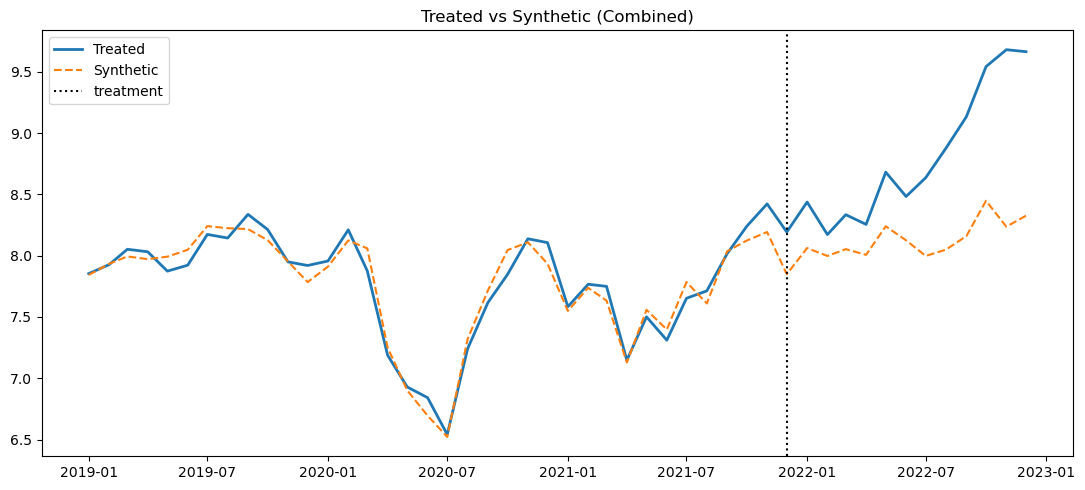

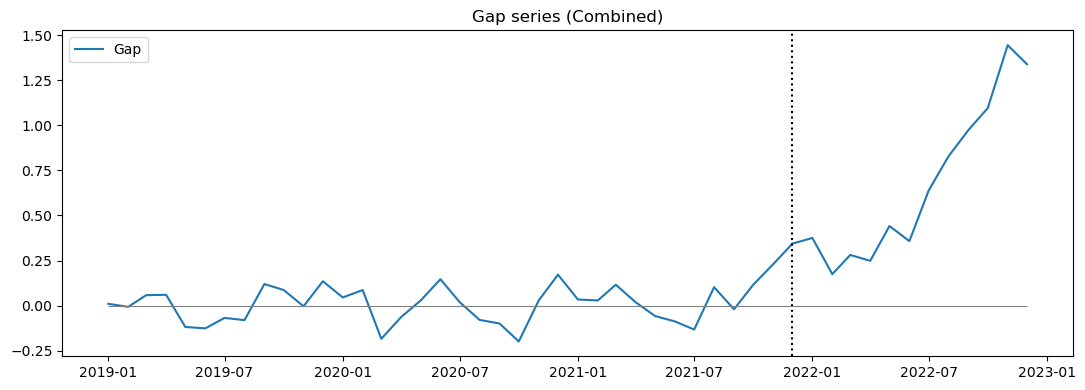

Pre-fit validity (Combined): {'pre_r2': 0.9458, 'pre_corr': 0.9728, 'pre_mape': 0.0844, 'pre_gap_slope': 0.0015, 'pre_gap_trend_p': 0.3826}


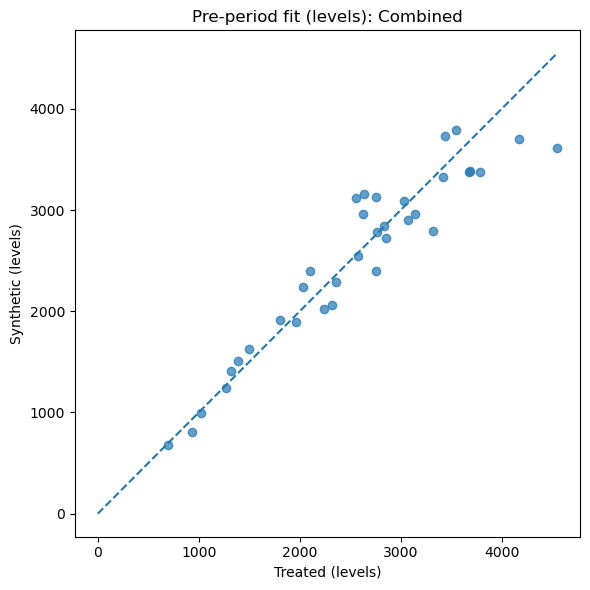

<Figure size 640x480 with 0 Axes>

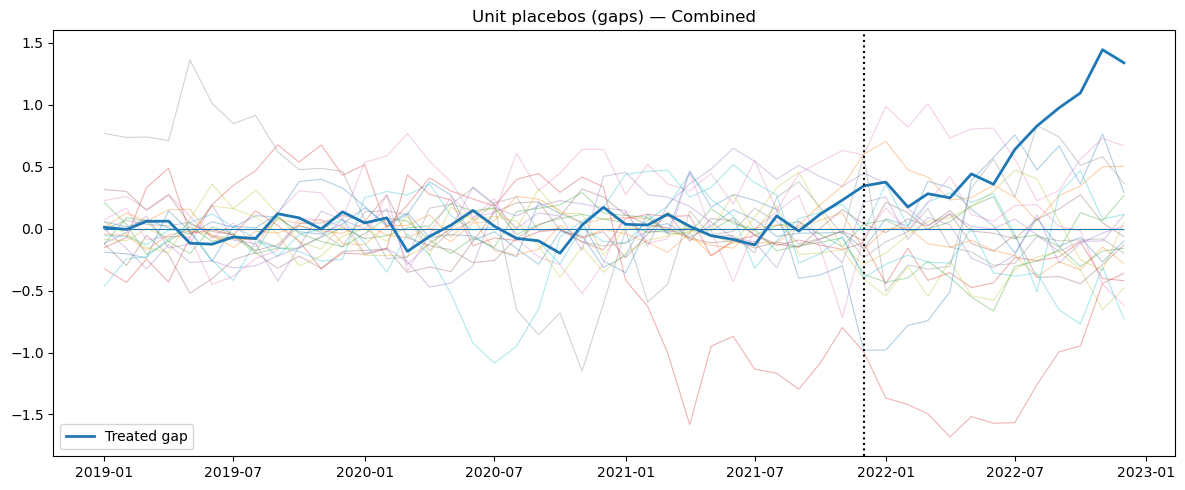

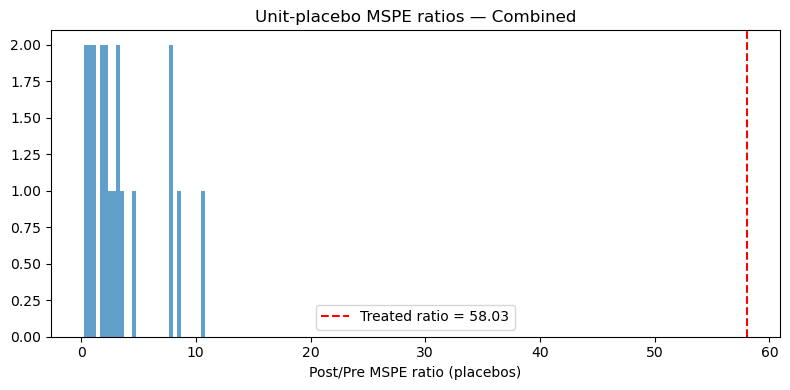

=== Synthetic Control Summary (spec) === scale=log; group>=0.3; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors      0.102       0.778                58.03                0.048          20               54074.87               122.37
                    Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
               Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE)      0.151       1.083                51.73                0.050          19               67032.23               214.63


month-placebos: 100%|██████████████████████████| 12/12 [00:00<00:00, 283.90it/s]


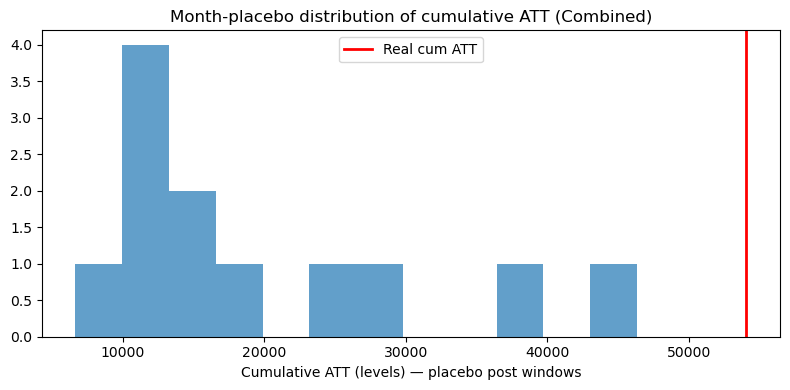

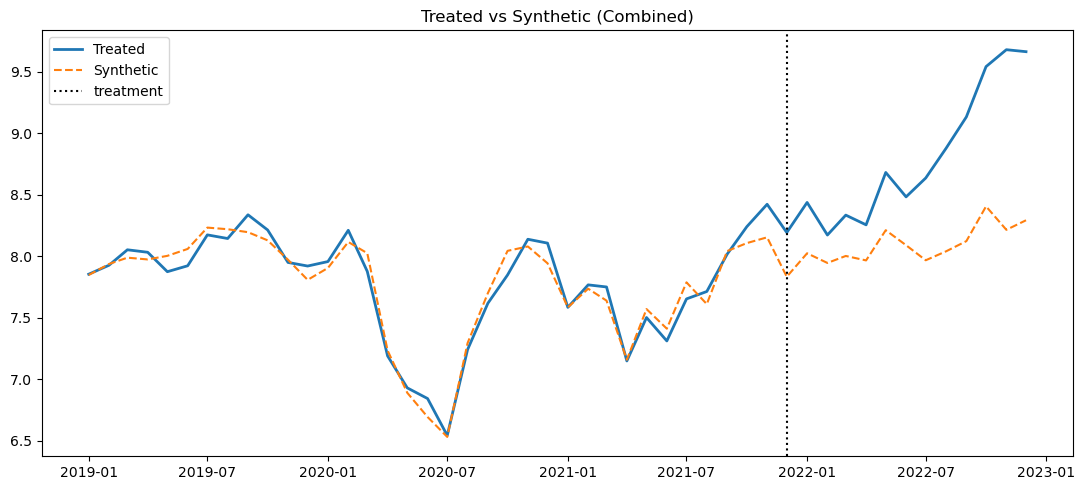

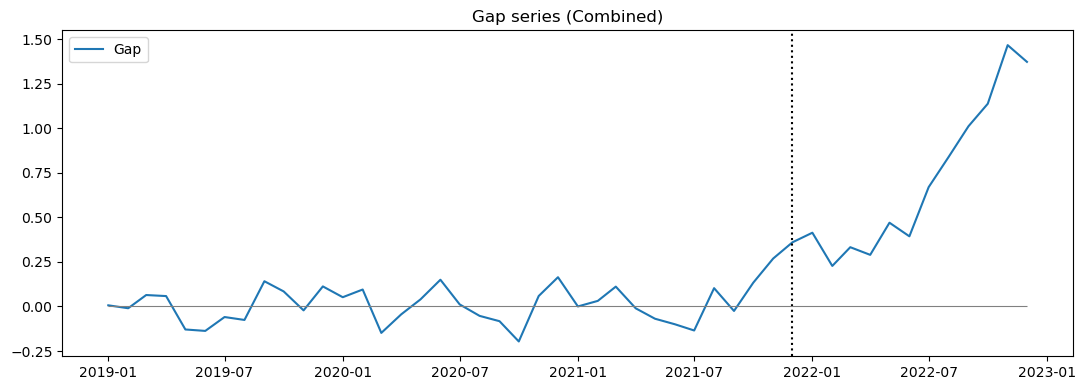

Pre-fit validity (Combined): {'pre_r2': 0.9438, 'pre_corr': 0.9718, 'pre_mape': 0.0844, 'pre_gap_slope': 0.0016, 'pre_gap_trend_p': 0.3672}


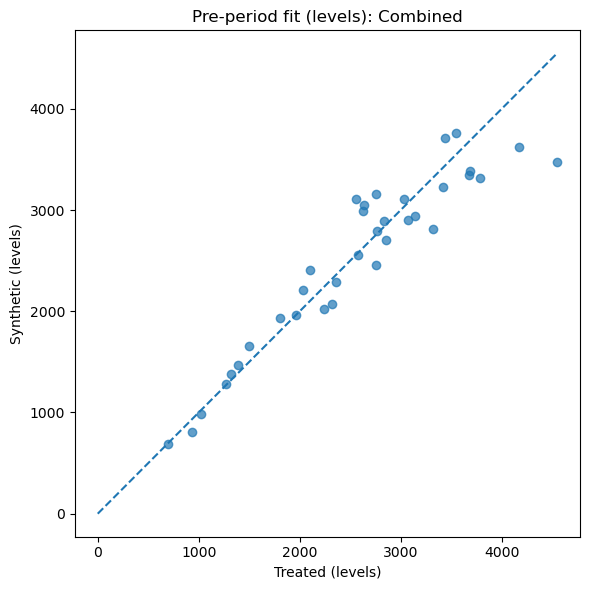

<Figure size 640x480 with 0 Axes>

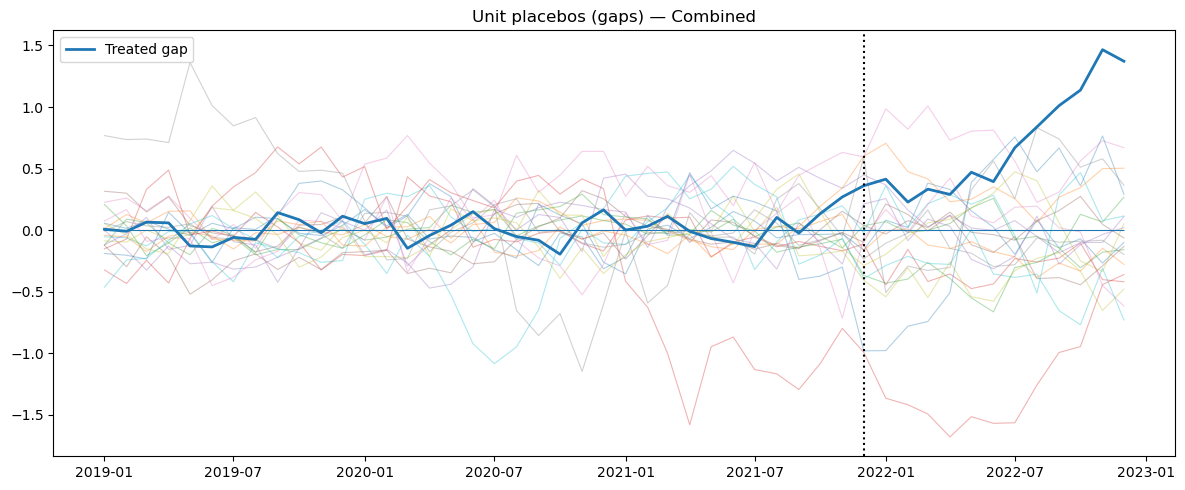

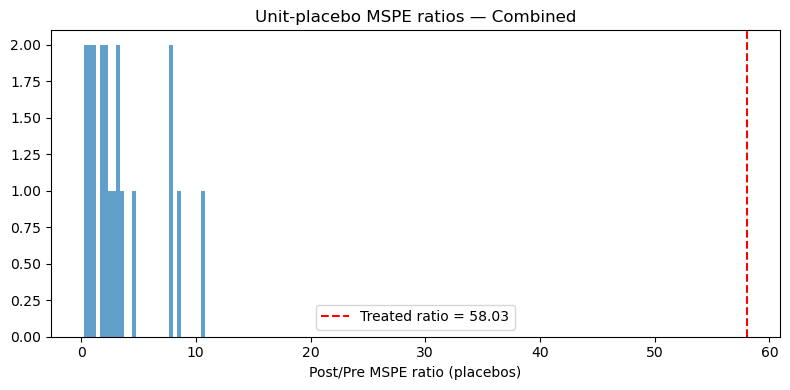

=== Synthetic Control Summary (spec) === scale=log; group>=0.3; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)      0.104       0.805                59.86                0.048          20               55549.40               130.05
                              Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
                         Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE, cap 0.50)      0.151       1.083                51.73                0.050          19               67032.23               214.63


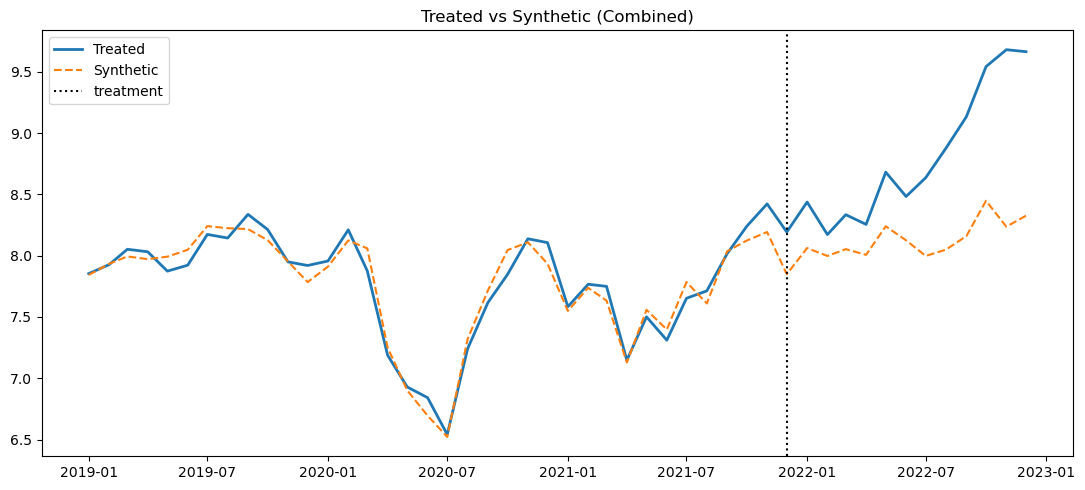

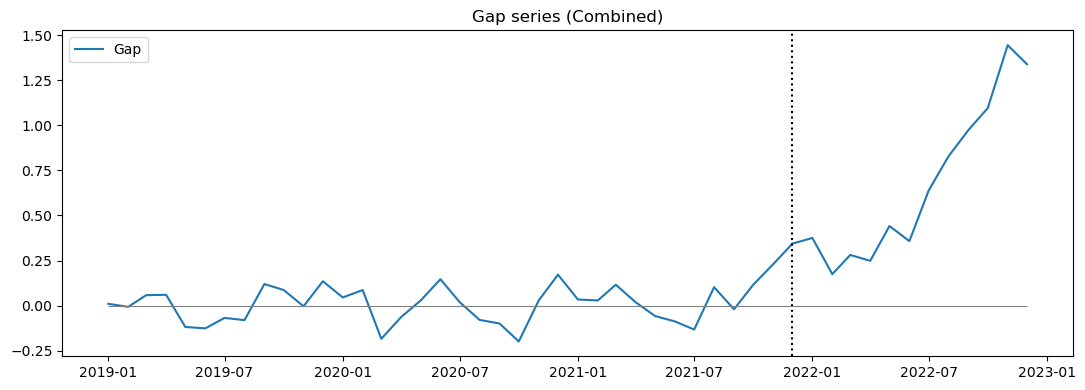

Pre-fit validity (Combined): {'pre_r2': 0.9458, 'pre_corr': 0.9728, 'pre_mape': 0.0844, 'pre_gap_slope': 0.0015, 'pre_gap_trend_p': 0.3826}


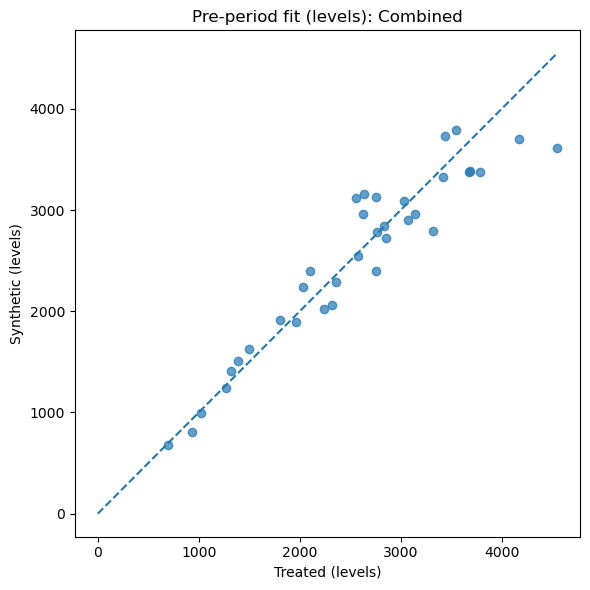

<Figure size 640x480 with 0 Axes>

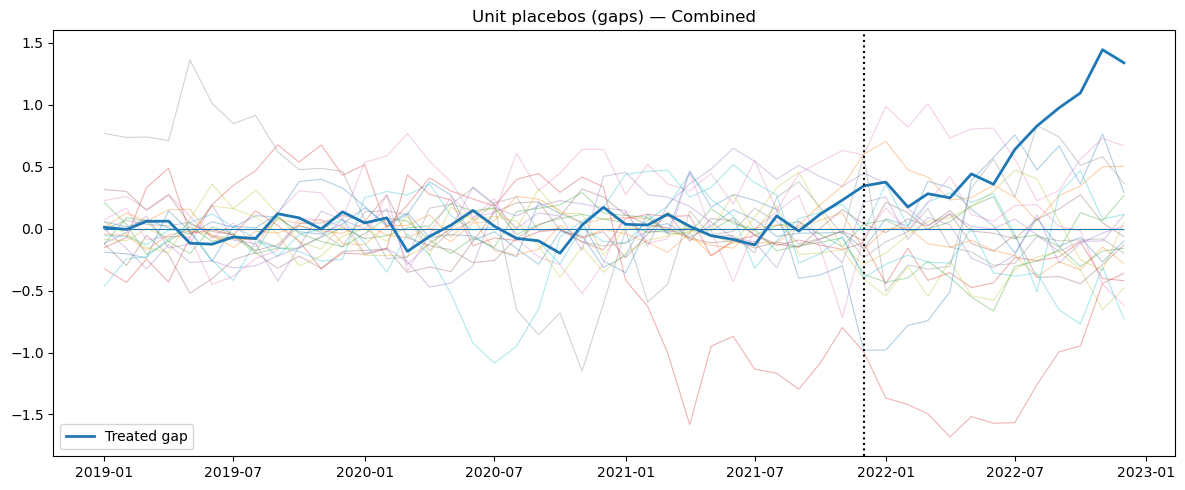

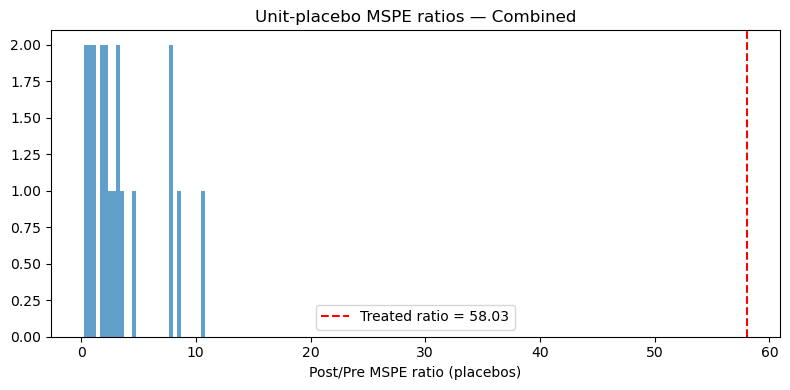

Share-of-US test: Post jump = 0.0199 (p=0.263), trend = 0.0004 (p=0.279)


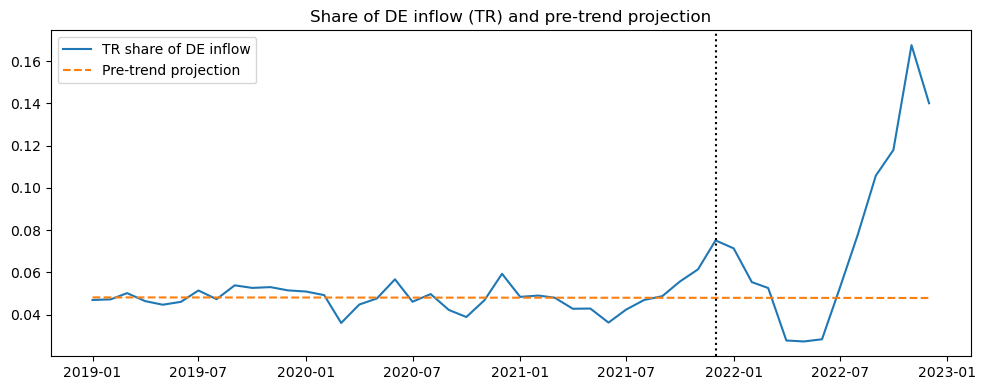

Average monthly post gap (levels): origin-only = 4896.3, destination-only = 4904.2


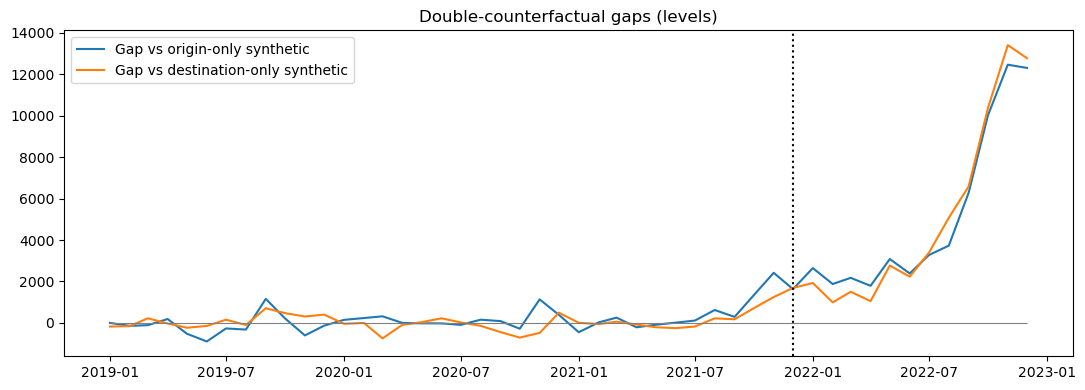

=== Synthetic Control Summary (spec) === scale=log; group>=0.4; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors      0.102       0.778                58.03                0.048          20               54074.87               122.37
                    Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
               Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE)      0.151       1.083                51.73                0.050          19               67032.23               214.63


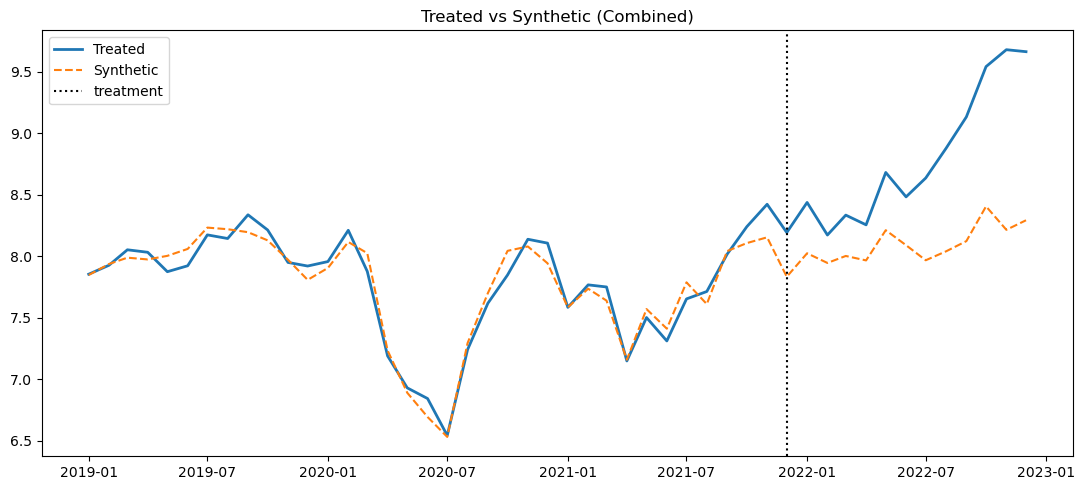

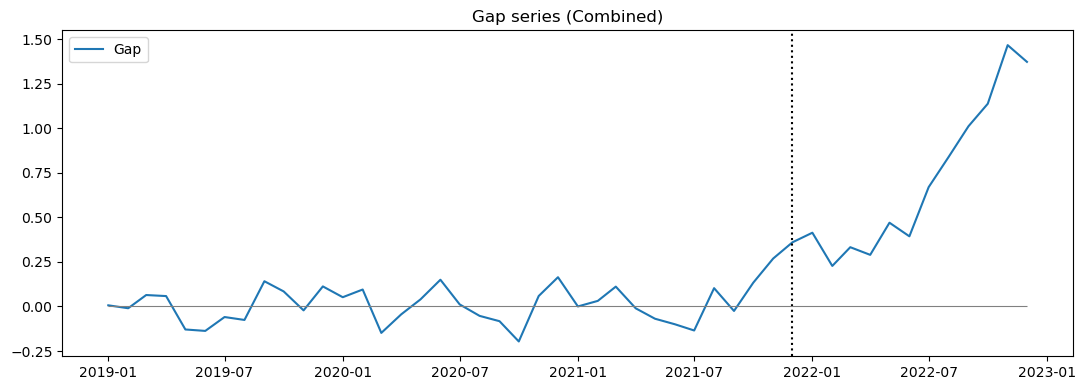

Pre-fit validity (Combined): {'pre_r2': 0.9438, 'pre_corr': 0.9718, 'pre_mape': 0.0844, 'pre_gap_slope': 0.0016, 'pre_gap_trend_p': 0.3672}


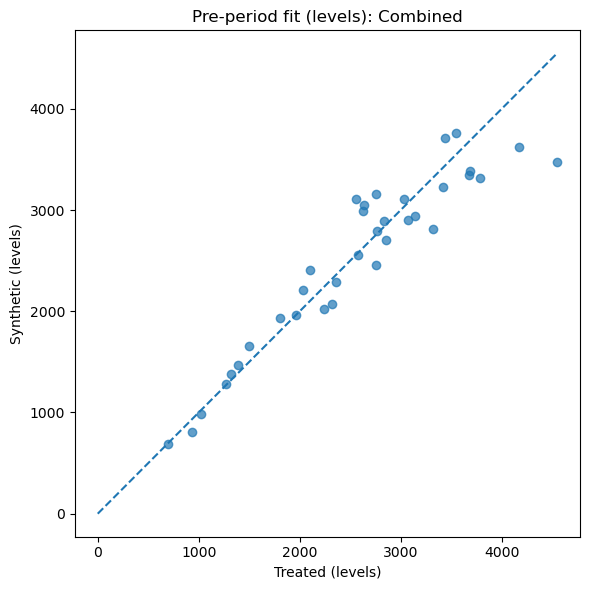

<Figure size 640x480 with 0 Axes>

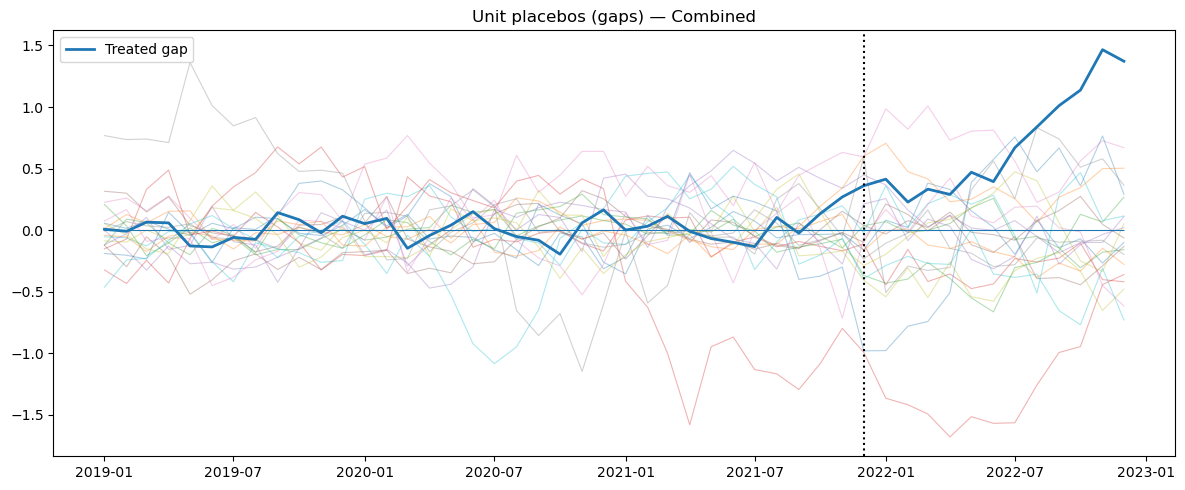

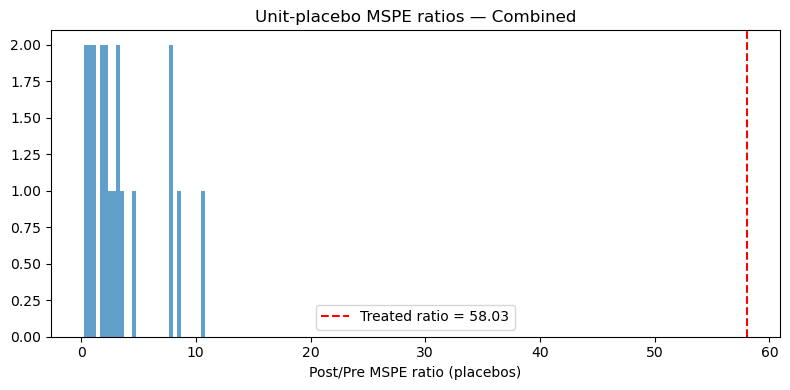

=== Synthetic Control Summary (spec) === scale=log; group>=0.4; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)      0.104       0.805                59.86                0.048          20               55549.40               130.05
                              Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
                         Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE, cap 0.50)      0.151       1.083                51.73                0.050          19               67032.23               214.63


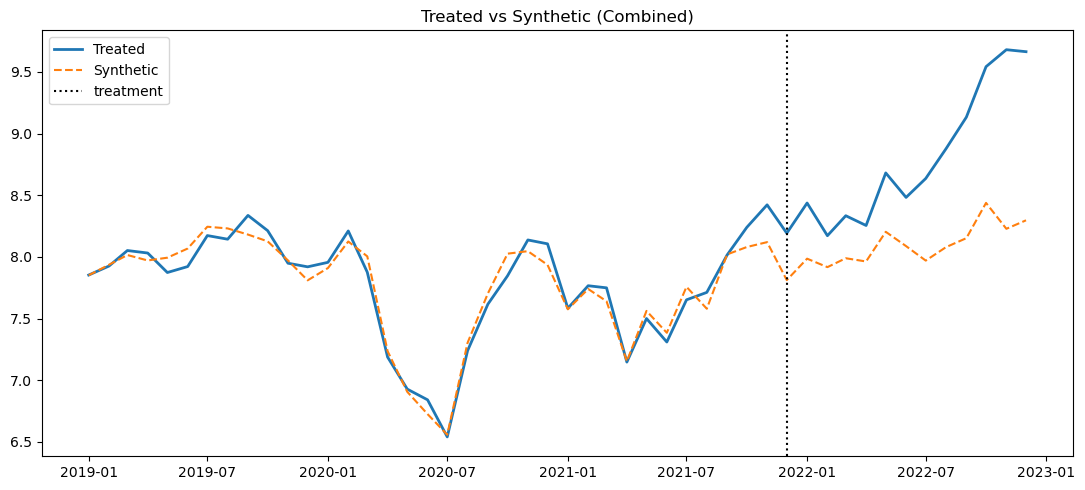

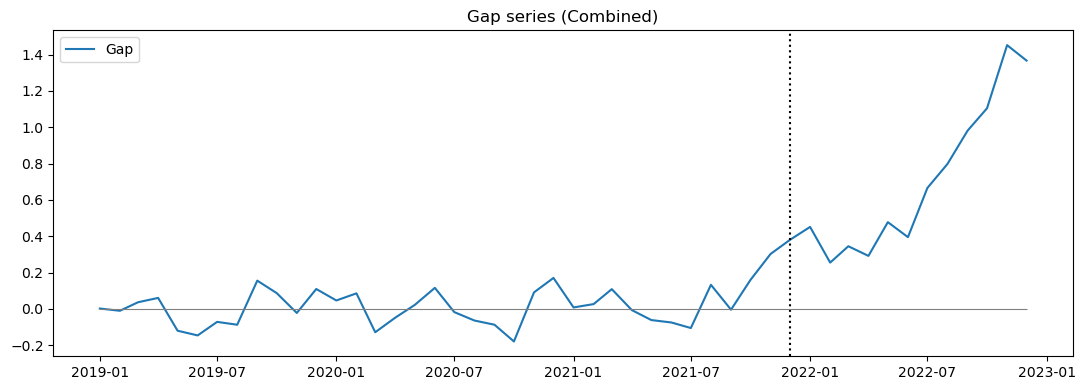

Pre-fit validity (Combined): {'pre_r2': 0.9422, 'pre_corr': 0.9713, 'pre_mape': 0.083, 'pre_gap_slope': 0.0025, 'pre_gap_trend_p': 0.155}


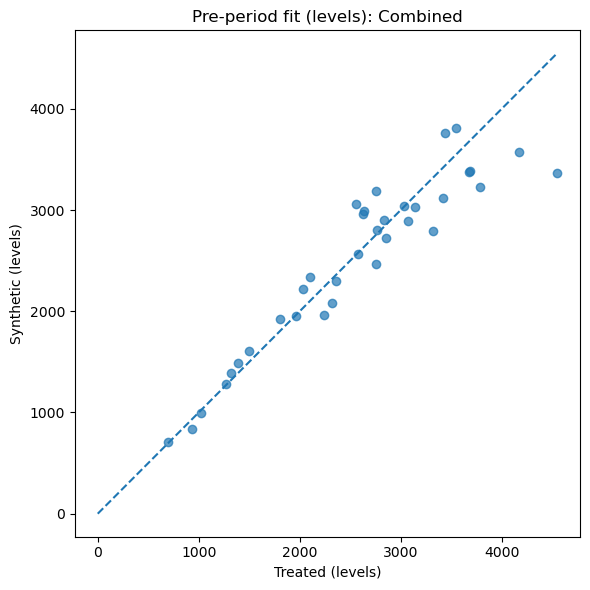

<Figure size 640x480 with 0 Axes>

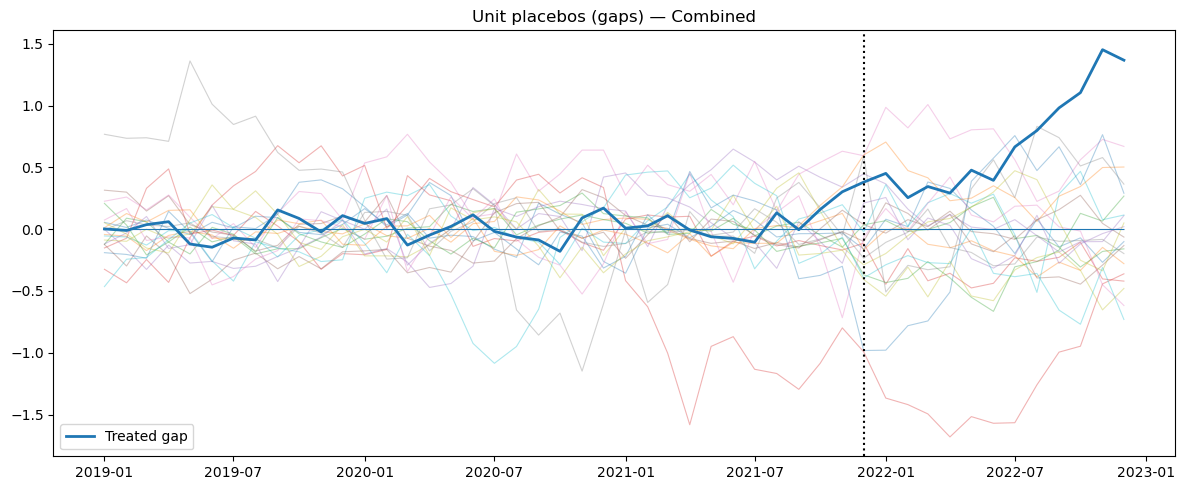

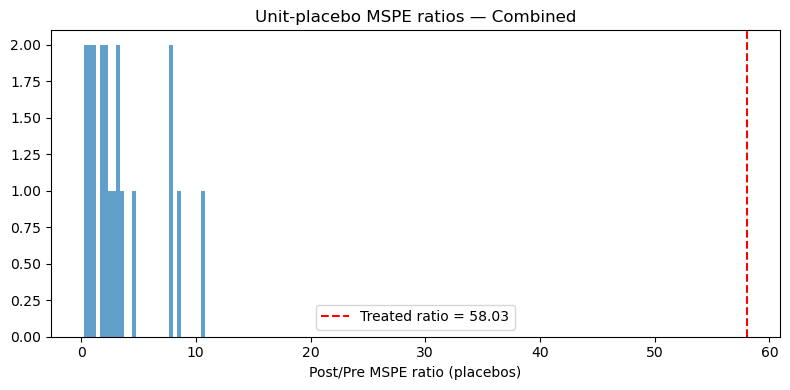

=== Synthetic Control Summary (spec) === scale=log; group>=0.5; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors      0.105       0.796                57.01                0.048          20               55409.11               129.29
                    Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
               Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE)      0.152       1.048                47.79                0.050          19               65923.76               203.84


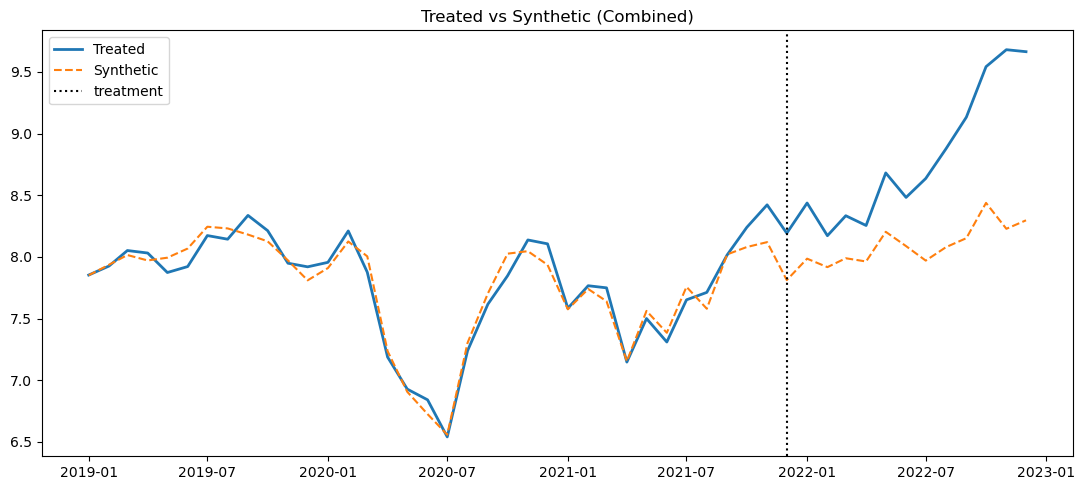

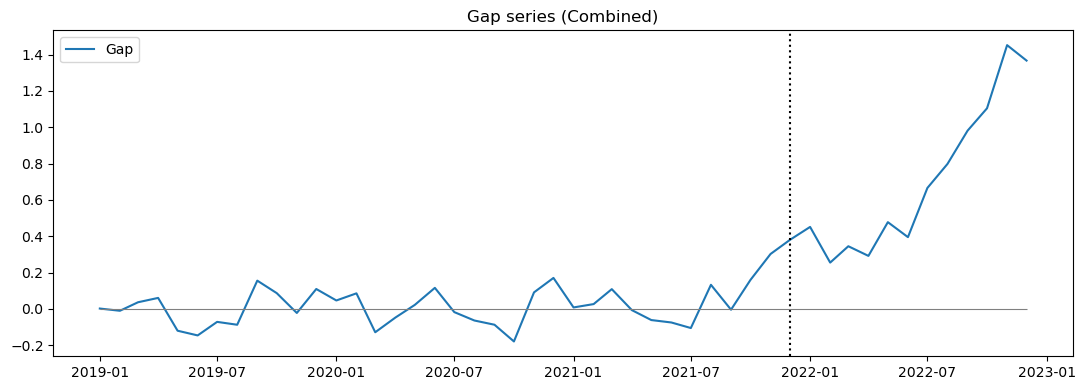

Pre-fit validity (Combined): {'pre_r2': 0.9422, 'pre_corr': 0.9713, 'pre_mape': 0.083, 'pre_gap_slope': 0.0025, 'pre_gap_trend_p': 0.155}


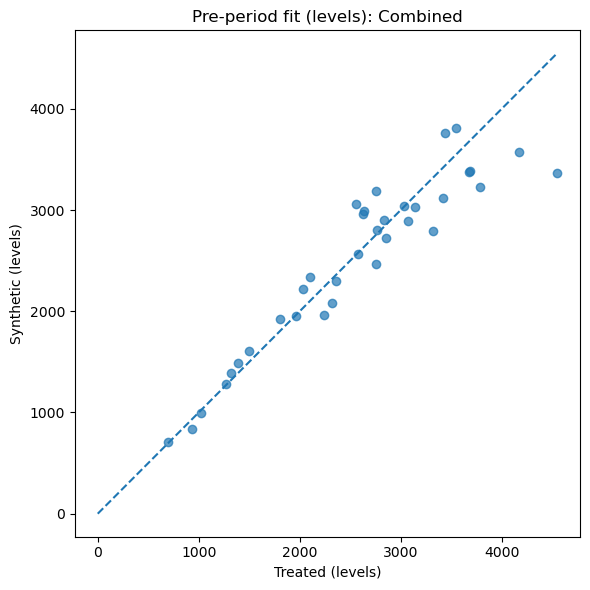

<Figure size 640x480 with 0 Axes>

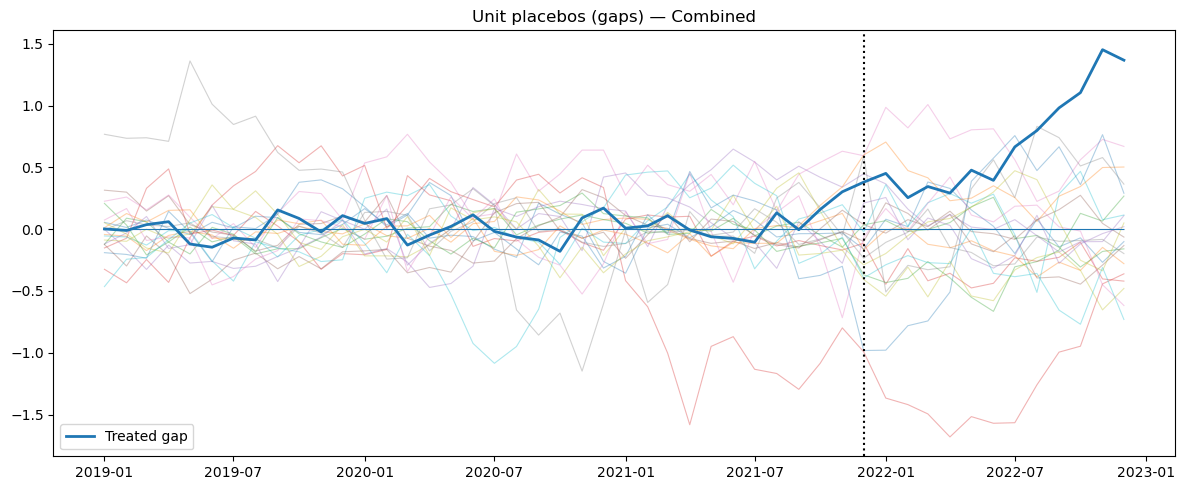

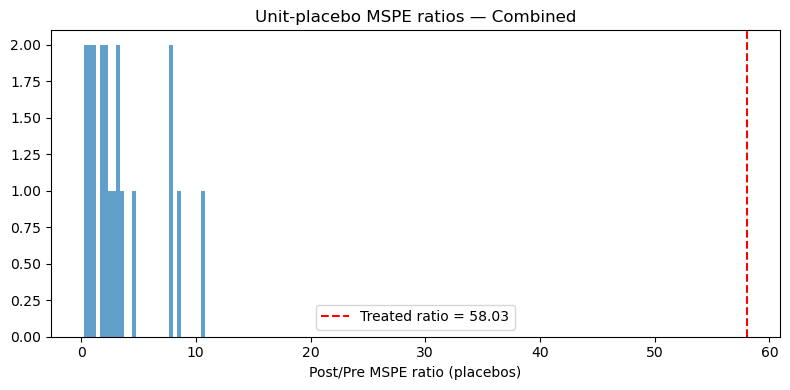

=== Synthetic Control Summary (spec) === scale=log; group>=0.5; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)      0.105       0.796                57.01                0.048          20               55409.35               129.30
                              Origin-only donors      0.207       0.976                22.28                0.091          10               63652.14               183.90
                         Destination-only donors      0.133       1.027                59.73                0.091          10               63754.14               184.74
Combined (leave top donor out: RO->DE, cap 0.50)      0.152       1.048                47.79                0.050          19               65923.74               203.84


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


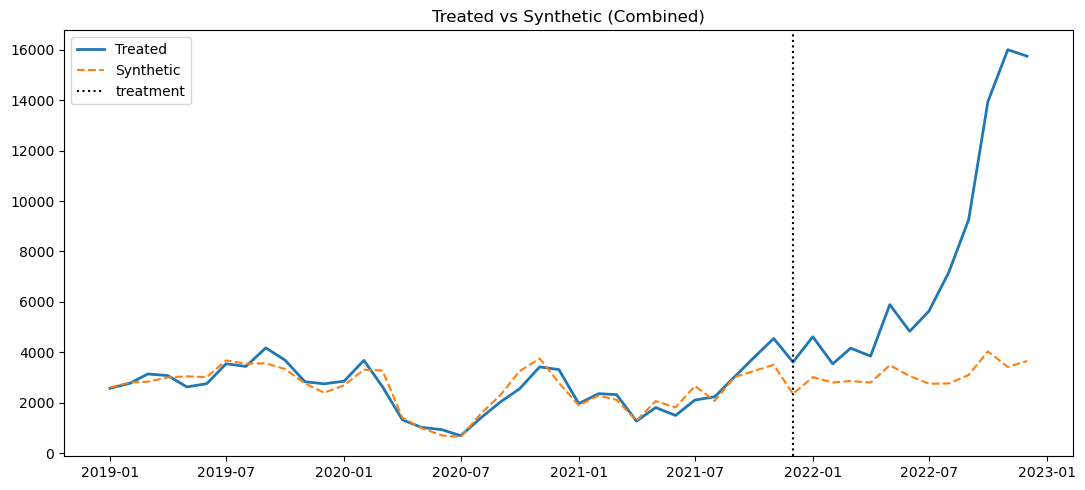

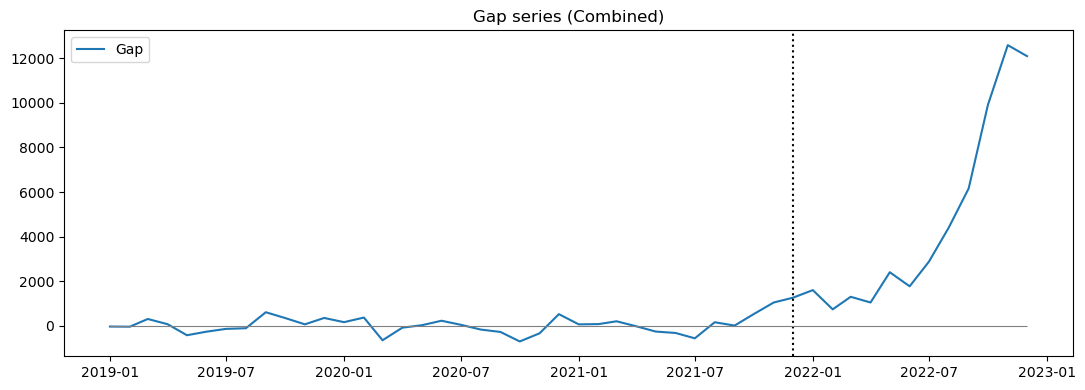

Pre-fit validity (Combined): {'pre_r2': 0.8508, 'pre_corr': 0.9231, 'pre_mape': 0.1055, 'pre_gap_slope': 2.9692, 'pre_gap_trend_p': 0.6344}


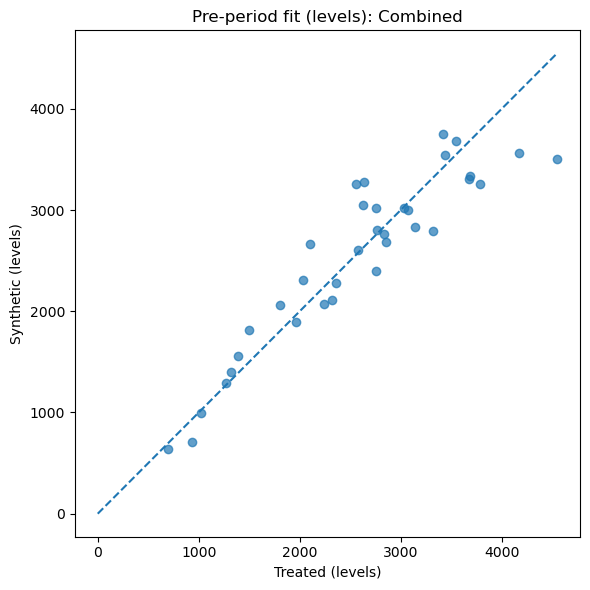

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

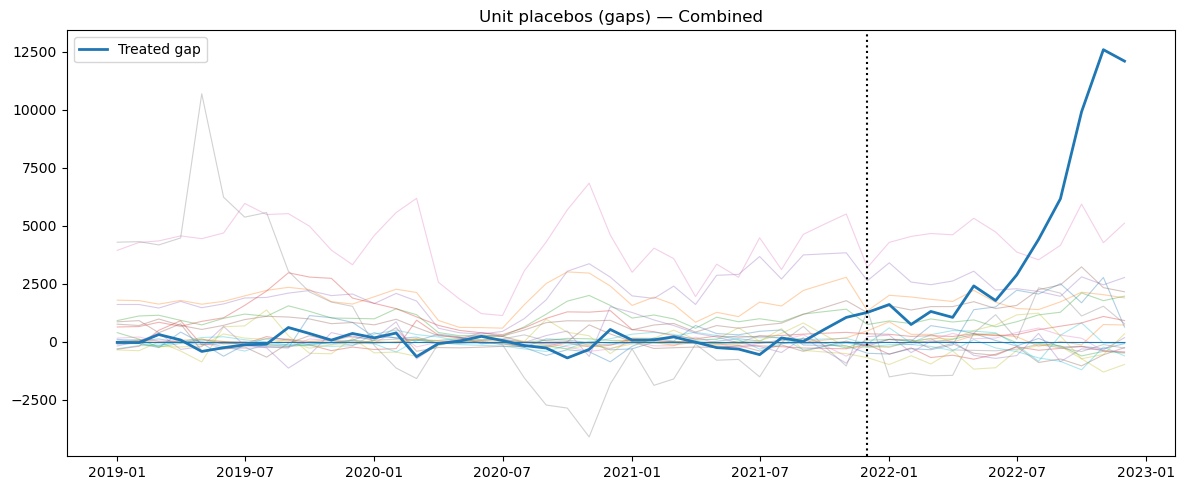

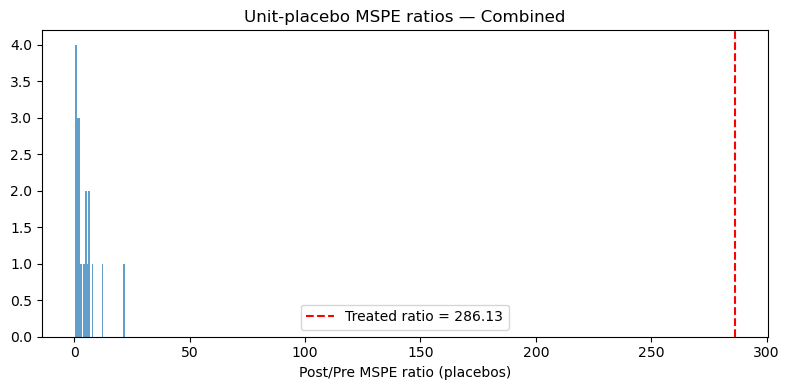

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Synthetic Control Summary (spec) === scale=raw; group>=0.3; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors    361.003    6106.463               286.13                0.048          20               58157.15               145.01
                    Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
               Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE)    467.277    6662.239               203.28                0.150          19               66642.56               210.75


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


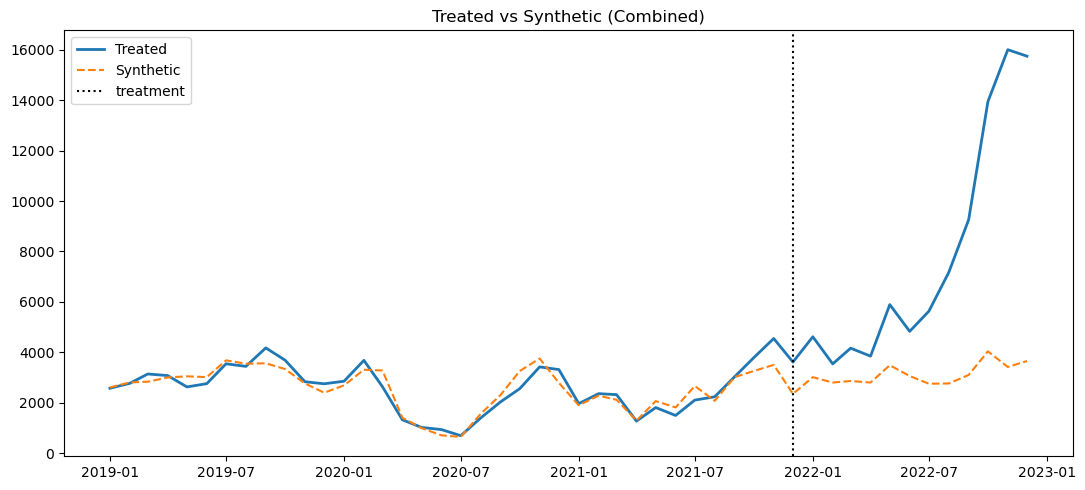

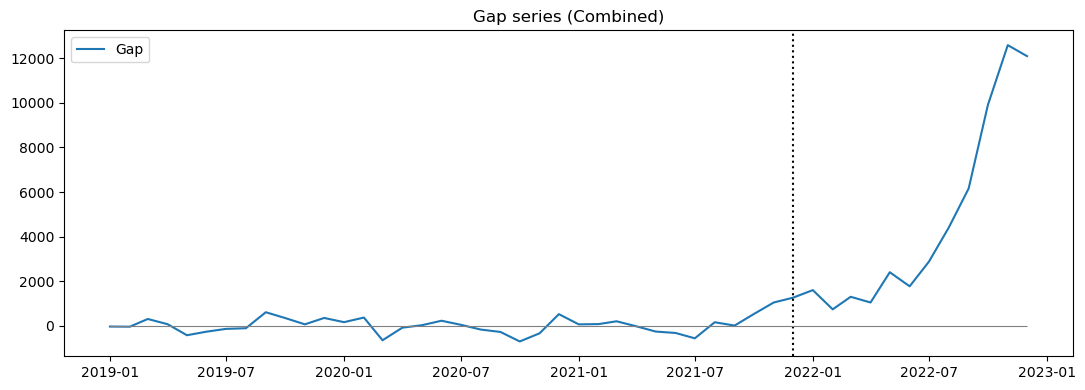

Pre-fit validity (Combined): {'pre_r2': 0.8508, 'pre_corr': 0.9231, 'pre_mape': 0.1055, 'pre_gap_slope': 2.9693, 'pre_gap_trend_p': 0.6344}


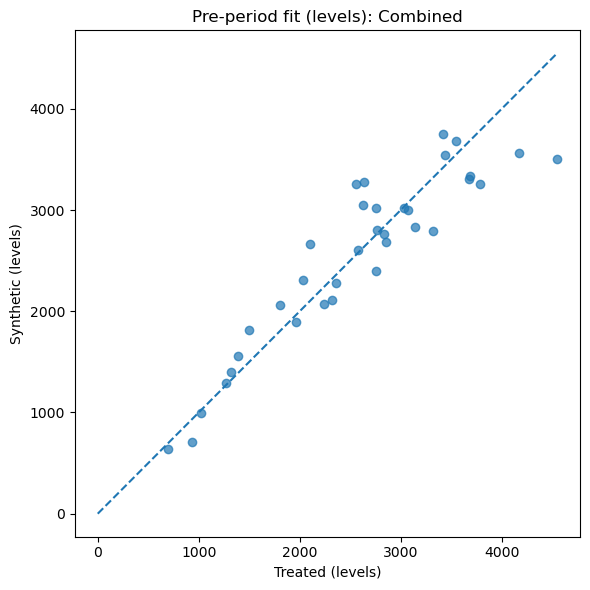

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

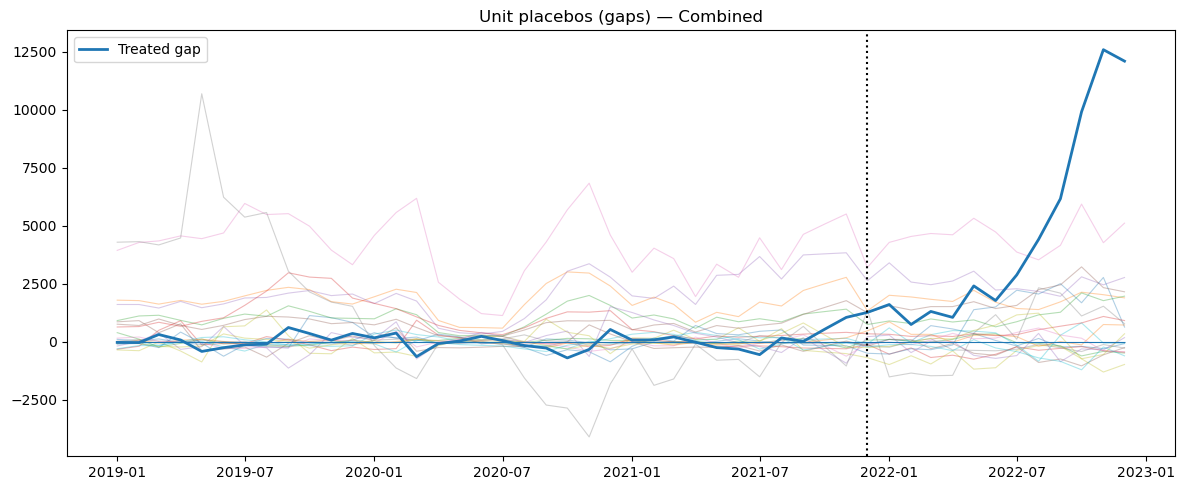

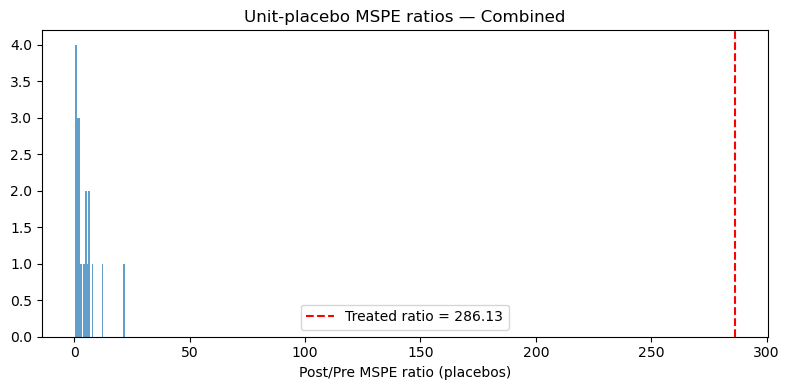

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Synthetic Control Summary (spec) === scale=raw; group>=0.3; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)    361.003    6106.462               286.13                0.048          20               58157.14               145.01
                              Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
                         Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE, cap 0.50)    467.279    6662.236               203.28                0.150          19               66642.57               210.75


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


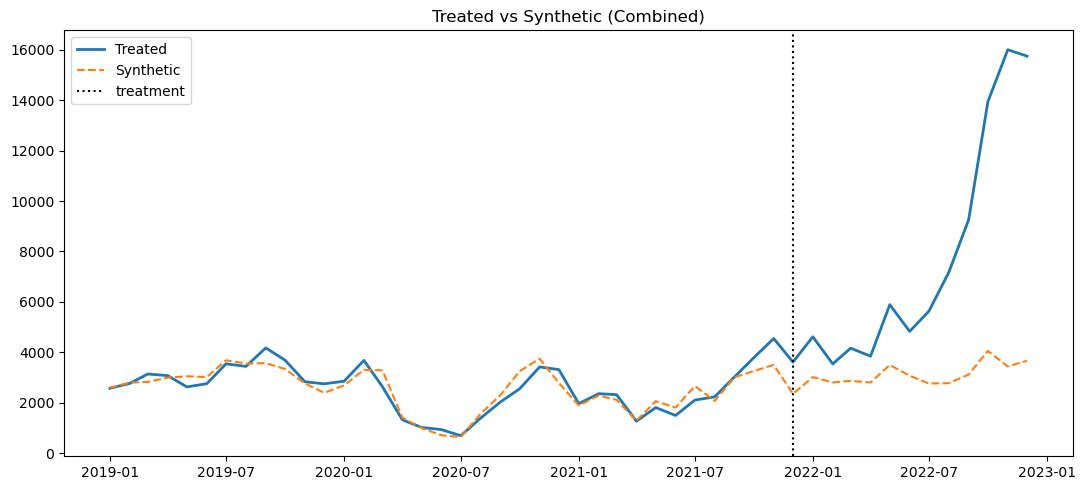

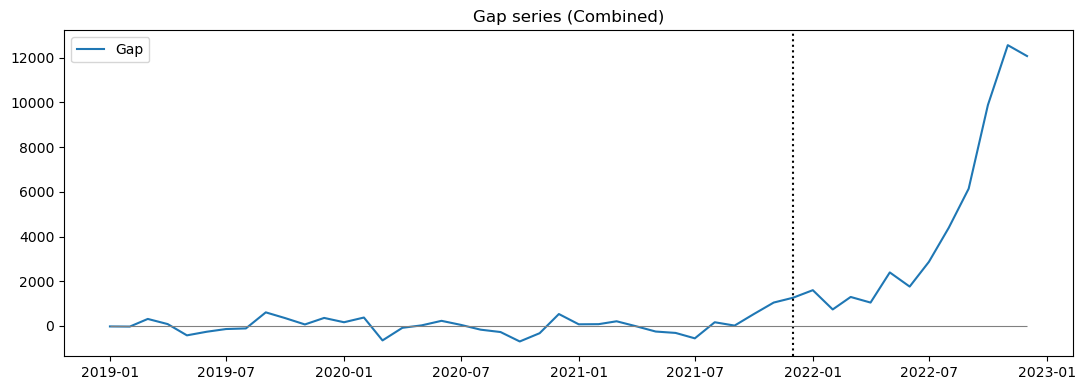

Pre-fit validity (Combined): {'pre_r2': 0.8507, 'pre_corr': 0.9231, 'pre_mape': 0.1055, 'pre_gap_slope': 2.9942, 'pre_gap_trend_p': 0.6315}


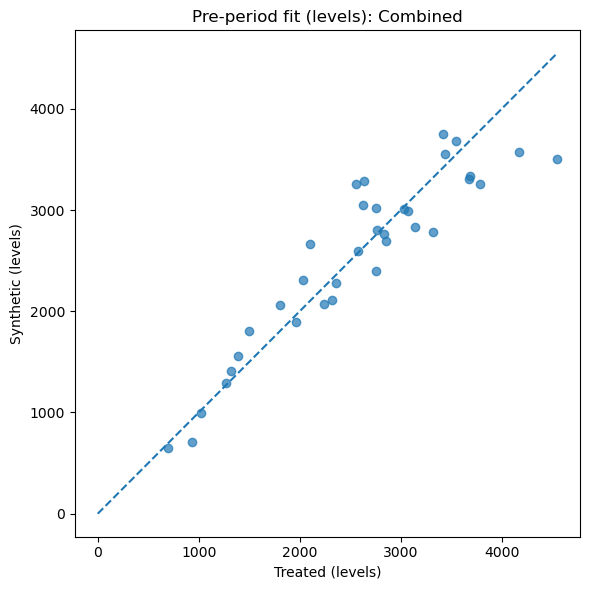

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

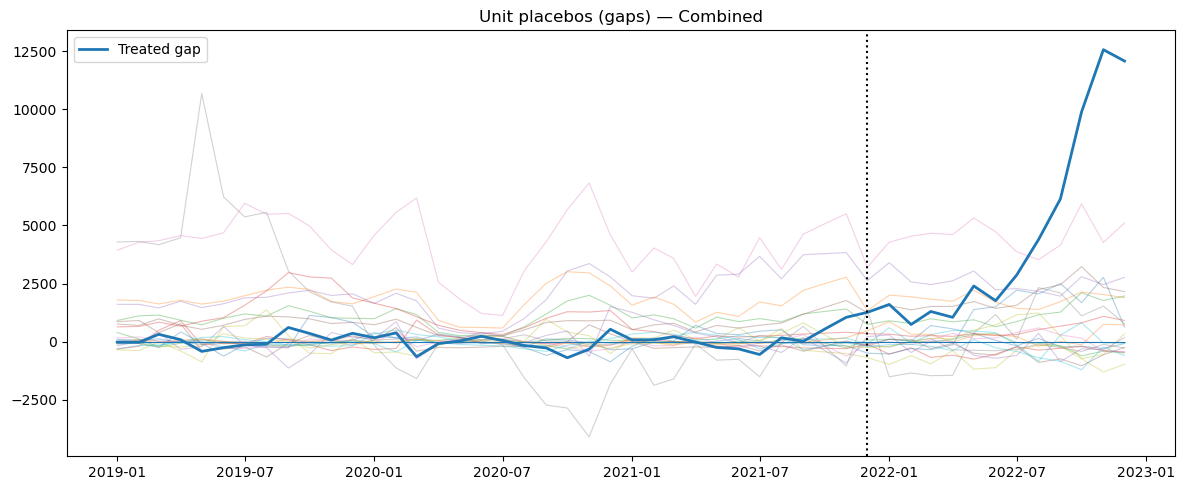

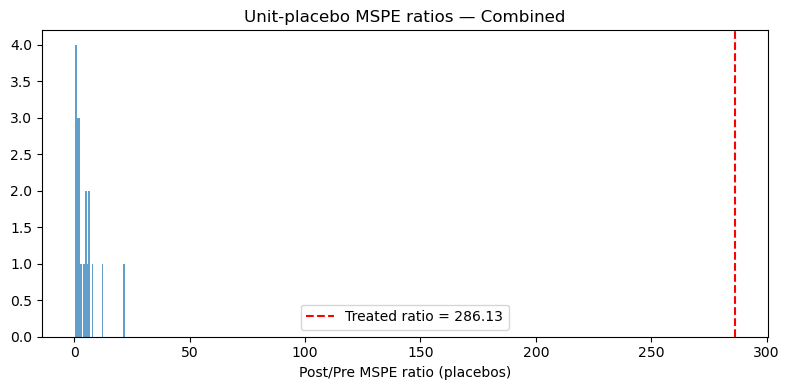

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Synthetic Control Summary (spec) === scale=raw; group>=0.4; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors    361.024    6095.732               285.09                0.048          20               58022.33               144.18
                    Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
               Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE)    478.320    6566.099               188.44                0.150          19               65506.67               199.98


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


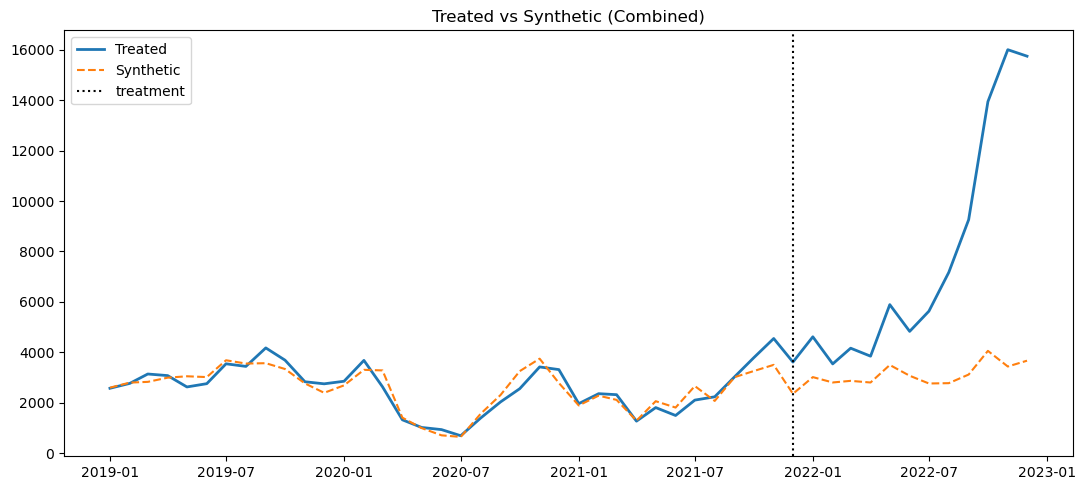

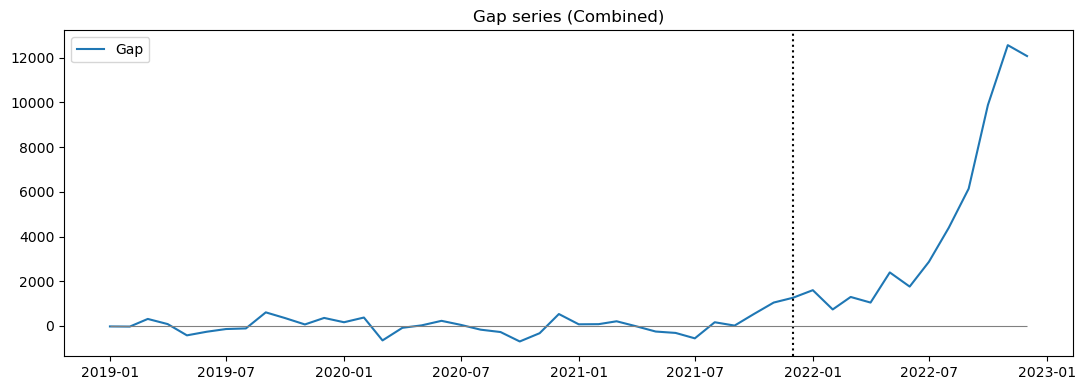

Pre-fit validity (Combined): {'pre_r2': 0.8507, 'pre_corr': 0.9231, 'pre_mape': 0.1055, 'pre_gap_slope': 2.9942, 'pre_gap_trend_p': 0.6315}


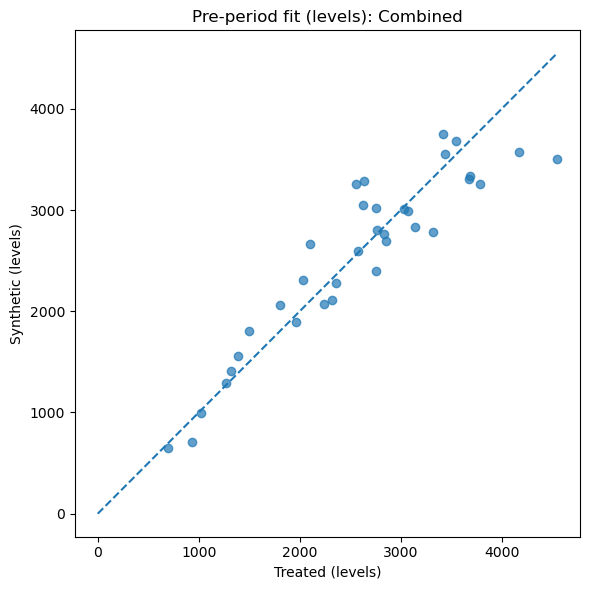

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

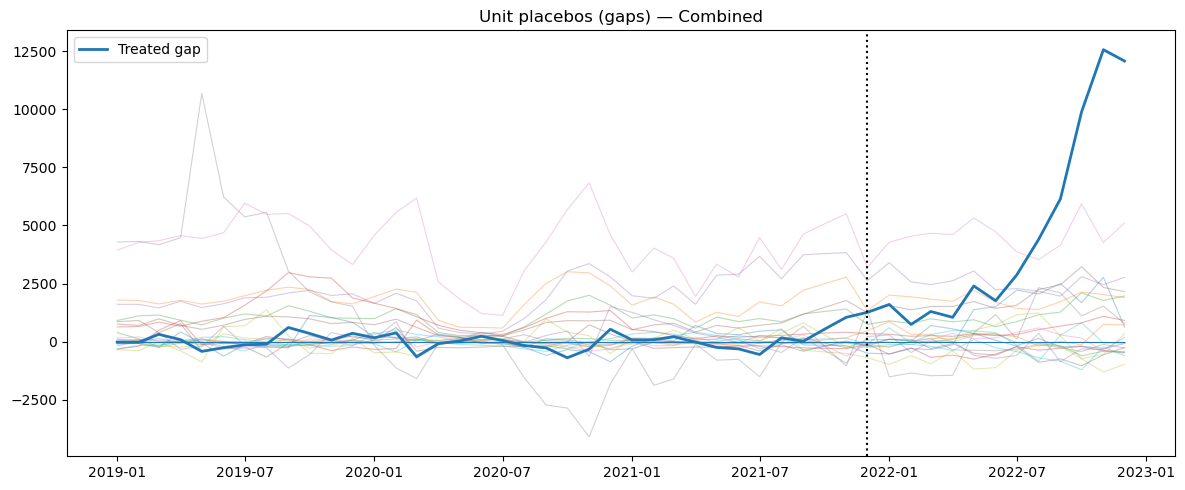

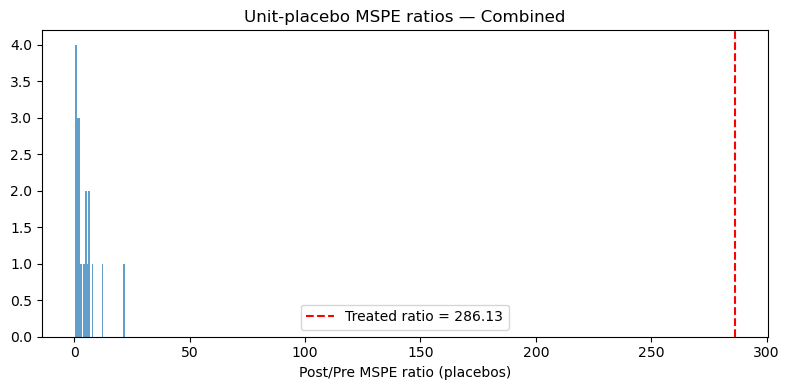

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Synthetic Control Summary (spec) === scale=raw; group>=0.4; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)    361.024    6095.734               285.09                0.048          20               58022.36               144.18
                              Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
                         Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE, cap 0.50)    478.319    6566.100               188.44                0.150          19               65506.65               199.98


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


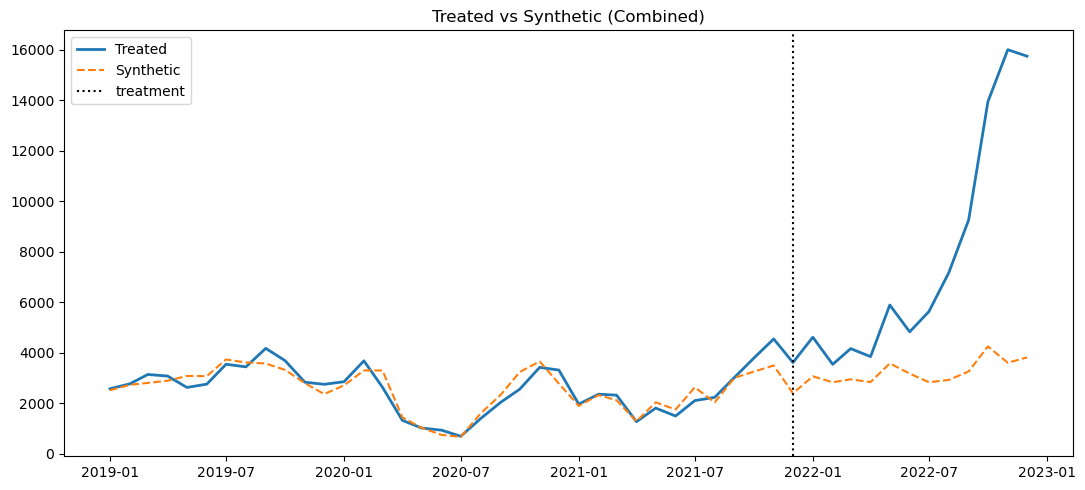

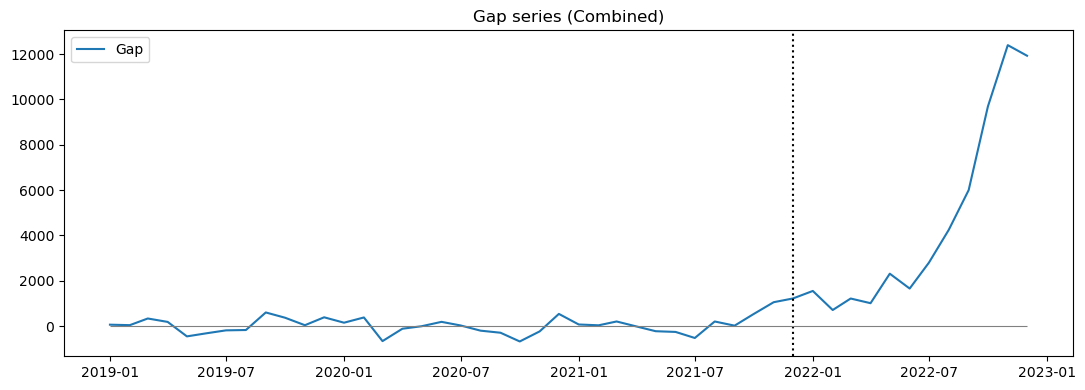

Pre-fit validity (Combined): {'pre_r2': 0.8481, 'pre_corr': 0.922, 'pre_mape': 0.1054, 'pre_gap_slope': 3.0614, 'pre_gap_trend_p': 0.6266}


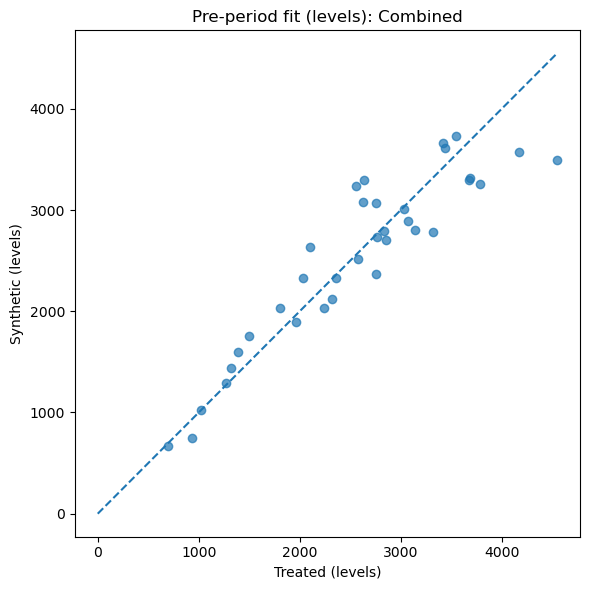

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

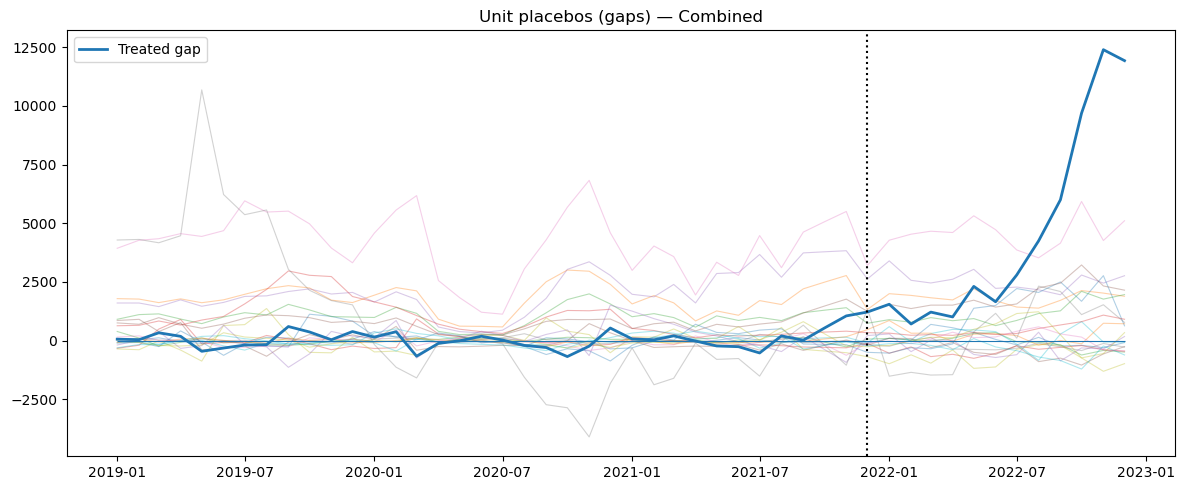

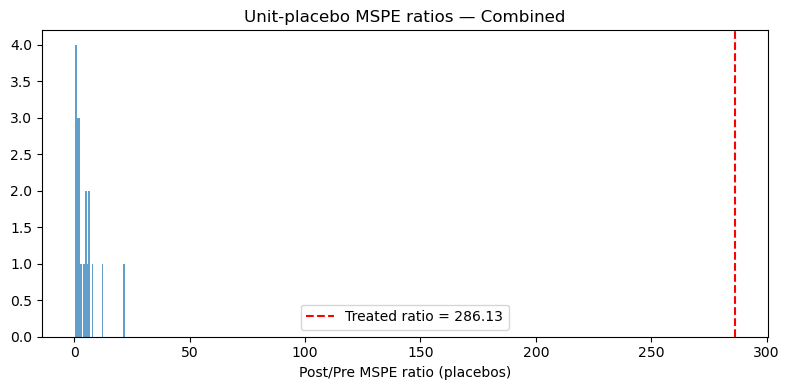

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Synthetic Control Summary (spec) === scale=raw; group>=0.5; cap=None
                                 Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                       Combined donors    364.171    5992.722               270.79                0.048          20               56735.35               136.62
                    Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
               Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE)    494.423    6483.583               171.96                0.150          19               64563.39               191.58


/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


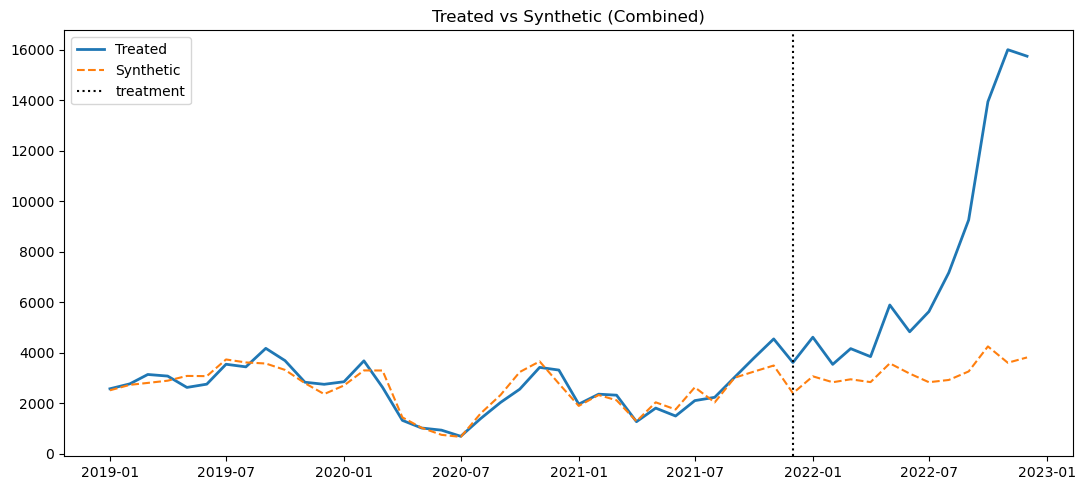

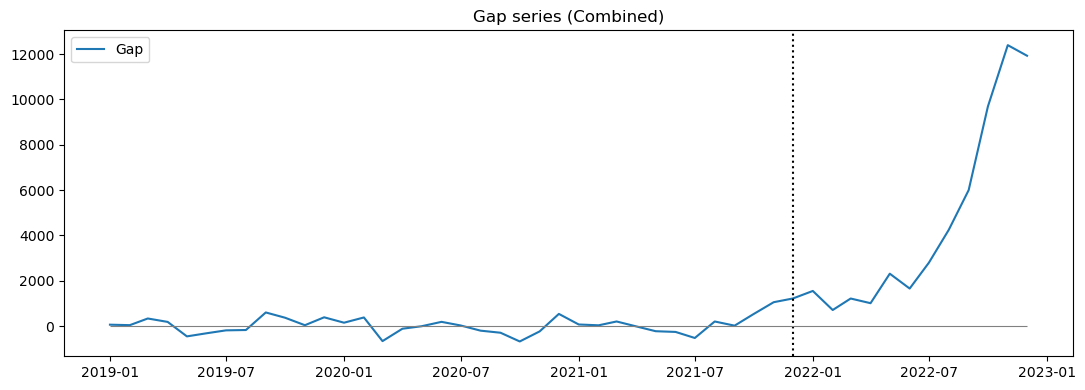

Pre-fit validity (Combined): {'pre_r2': 0.8481, 'pre_corr': 0.922, 'pre_mape': 0.1054, 'pre_gap_slope': 3.0615, 'pre_gap_trend_p': 0.6266}


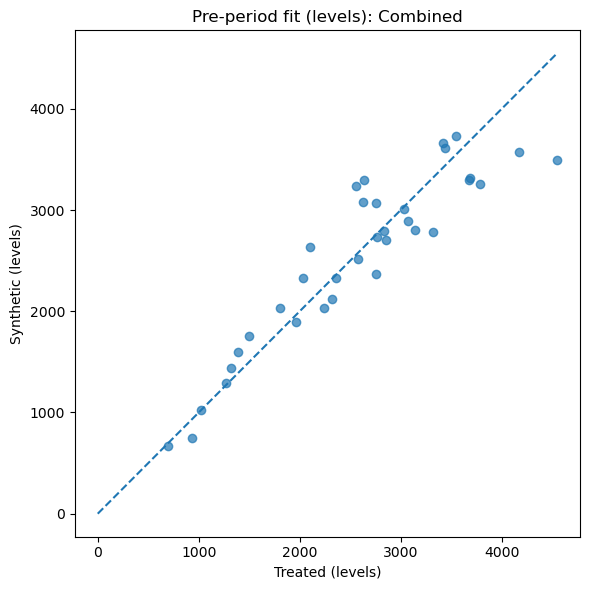

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

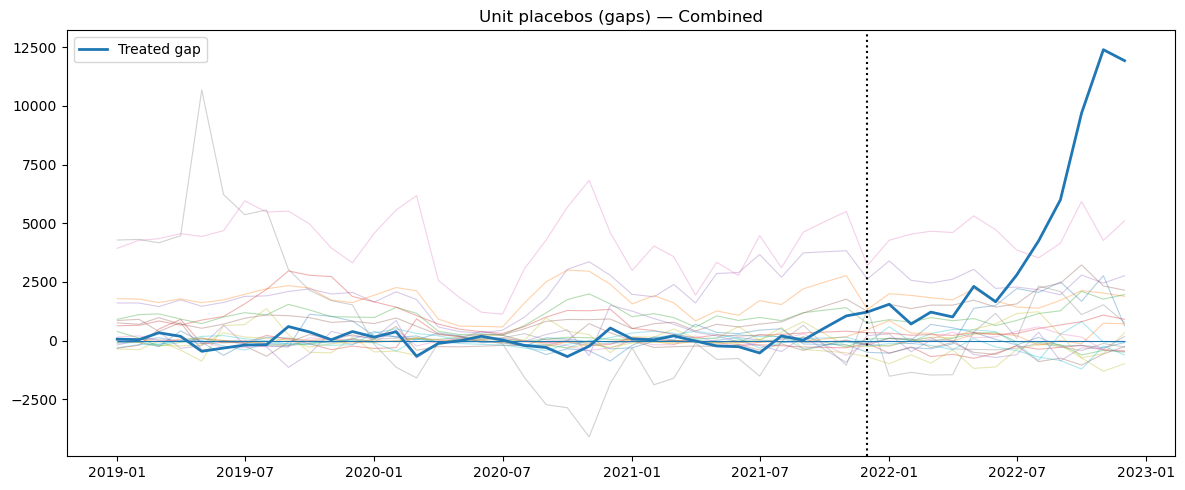

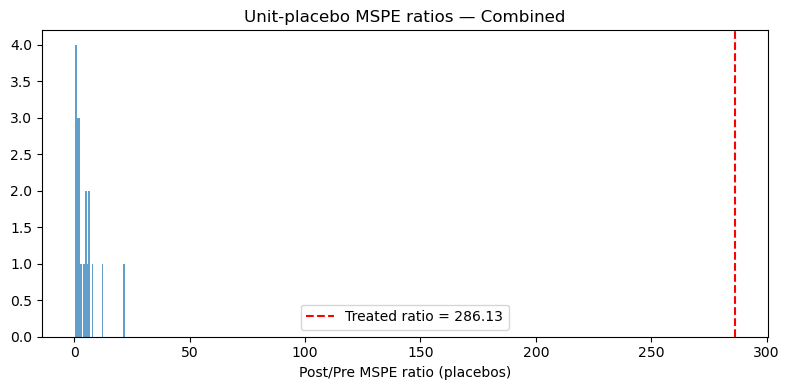

=== Synthetic Control Summary (spec) === scale=raw; group>=0.5; cap=0.5
                                           Model  Pre_RMSPE  Post_RMSPE  Post/Pre_MSPE_Ratio  Permutation_p_value  N_placebos  Cumulative_ATT_levels  Percent_change_post
                      Combined donors (cap 0.50)    364.171    5992.720               270.79                0.048          20               56735.32               136.62
                              Origin-only donors    652.330    6279.402                92.66                0.091          10               63091.66               179.38
                         Destination-only donors    395.644    6517.112               271.33                0.091          10               63129.01               179.68
Combined (leave top donor out: RO->DE, cap 0.50)    494.423    6483.577               171.96                0.150          19               64563.31               191.58
All scenarios completed. Results saved in: /Users/wenlanzhang/PycharmProjects/

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [26]:
# ----------------------------- All Result -----------------------------

if __name__ == "__main__":
    # 1) Load
    df = load_data(CSV_PATH)

    # 2) Treated monthly rows and donor selection by similarity
    treat_df = df[(df["country_to"] == TREATED_TO) & (df["country_from"] == TREATED_FROM)].copy()
    if treat_df.empty:
        raise ValueError(f"Treated flow {TREATED_FROM}->{TREATED_TO} not found in data.")

    same_origin_m, same_dest_m, treated_total = pick_similar_donors(
        df, TREATED_FROM, TREATED_TO, EXCLUDE_ORIGINS, TOP_K
    )

    # 3) Control dataframe and panel (levels)
    df_control = pd.concat([treat_df, same_origin_m, same_dest_m], ignore_index=True)
    panel = make_panel(df_control)

    treated_unit = f"{TREATED_FROM}->{TREATED_TO}"
    if treated_unit not in panel.columns:
        raise ValueError(f"Treated unit {treated_unit} not in panel columns.")

    # Build donor labels from the *levels* panel
    donors_dest_labels = [c for c in panel.columns if c.endswith(f"->{TREATED_TO}") and c != treated_unit]
    donors_orig_labels = [c for c in panel.columns if c.startswith(f"{TREATED_FROM}->") and c != treated_unit]
    donors_combined_labels = donors_dest_labels + donors_orig_labels

    # Scenarios to run
    log_opts = [True, False] if RUN_BOTH_LOG_SPECS else [USE_LOG]
    constraint_opts = CONSTRAINT_LEVELS if RUN_SENSITIVITY_CONSTRAINTS else [MIN_GROUP_SHARE]

    scenarios = []
    for use_log in log_opts:
        for grp in constraint_opts:
            scenarios.append((use_log, grp, None, "base"))
            if RUN_WEIGHT_CAP_VARIANT:
                scenarios.append((use_log, grp, WEIGHT_CAP, "cap"))

    ensure_dir(OUTPUT_DIR)

    first_spec_done = False

    for (use_log, grp_share, weight_cap, tag) in scenarios:
        # 4) Build Y on chosen scale
        Y = panel.copy()
        if use_log:
            Y = pd.DataFrame(np.log1p(Y.values), index=Y.index, columns=Y.columns)

        # masks
        pre_mask = np.asarray(Y.index < TREATMENT_DATE, dtype=bool)
        post_mask = np.asarray(Y.index >= TREATMENT_DATE, dtype=bool)
        T_pre = int(pre_mask.sum())
        if T_pre < MIN_PRE_MONTHS:
            print(f"Warning: only {T_pre} pre months (< {MIN_PRE_MONTHS}). Results may be unstable.")

        # donor DataFrames
        donor_df_combined = Y[donors_combined_labels]
        donor_df_origin = Y[donors_orig_labels]
        donor_df_dest = Y[donors_dest_labels]

        # group index maps for combined
        orig_idx = [donors_combined_labels.index(d) for d in donors_orig_labels if d in donors_combined_labels]
        dest_idx = [donors_combined_labels.index(d) for d in donors_dest_labels if d in donors_combined_labels]
        group_map = {"origin": orig_idx, "destination": dest_idx}

        y_t = Y[treated_unit].values
        dates = Y.index
        treat_idx = int(pre_mask.sum())

        # 5) Fit models for this spec
        results = []
        weights_store = {}

        # Combined
        if donor_df_combined.shape[1] >= 1:
            fr_c = fit_synth(y_t, donor_df_combined.values, pre_mask,
                             group_indices=group_map, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_c = diagnostics(y_t, fr_c.synth, pre_mask, post_mask, use_log)
            tr_c, placebo_c, pval_c, n_c = unit_placebos(y_t, donor_df_combined, pre_mask, post_mask)
            results.append({
                "Model": "Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})",
                "Pre_RMSPE": d_c["pre_rmspe"],
                "Post_RMSPE": d_c["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_c["mspe_ratio"],
                "Permutation_p_value": pval_c,
                "N_placebos": n_c,
                "Cumulative_ATT_levels": d_c["cum_att_levels"],
                "Percent_change_post": d_c["pct_change_post"] * 100.0,
            })
            weights_store["Combined donors" if weight_cap is None else f"Combined donors (cap {weight_cap:.2f})"] = pd.DataFrame({
                "donor": donors_combined_labels,
                "weight": fr_c.weights,
                "group": ["destination" if i in dest_idx else "origin" for i in range(len(donors_combined_labels))]
            }).sort_values("weight", ascending=False)

            # Plots & validity for combined
            plt.figure(figsize=(11, 5))
            plt.plot(dates, y_t, label="Treated", linewidth=2)
            plt.plot(dates, fr_c.synth, "--", label="Synthetic")
            plt.axvline(dates[treat_idx], color="k", linestyle=":", label="treatment")
            plt.title("Treated vs Synthetic (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("fit_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            plt.figure(figsize=(11, 4))
            plt.plot(dates, y_t - fr_c.synth, label="Gap")
            plt.axvline(dates[treat_idx], color="k", linestyle=":")
            plt.hlines(0, dates.min(), dates.max(), colors="gray", linewidth=0.8)
            plt.title("Gap series (Combined)")
            plt.legend(); plt.tight_layout()
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("gap_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))
            plt.show()

            metrics = pre_fit_validity_metrics(y_t, fr_c.synth, pre_mask, use_log)
            print("Pre-fit validity (Combined):",
                  {k: (round(v, 4) if isinstance(v, float) and np.isfinite(v) else v) for k, v in metrics.items()})
            plot_pre_fit_scatter(dates, y_t[pre_mask], fr_c.synth[pre_mask], use_log,
                                 title="Pre-period fit (levels): Combined")
            if SAVE_FIGS:
                figpath = OUTPUT_DIR / label_slug("prefit_scatter_combined", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                savefig(figpath.with_suffix('.png'))

            placebo_gaps_c = unit_placebo_gaps(y_t, donor_df_combined, pre_mask)
            if len(placebo_gaps_c) > 0:
                plt.figure(figsize=(12, 5))
                for g in placebo_gaps_c.values():
                    plt.plot(dates, g, linewidth=0.8, alpha=0.35)
                plt.plot(dates, y_t - fr_c.synth, linewidth=2.0, label='Treated gap')
                plt.axvline(dates[treat_idx], color='k', linestyle=':')
                plt.hlines(0, dates.min(), dates.max(), linewidth=0.8)
                plt.legend(); plt.title("Unit placebos (gaps) — Combined")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("unit_placebo_gaps", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                vals = np.array(list(placebo_c.values()))
                if vals.size > 0 and np.isfinite(tr_c):
                    plt.figure(figsize=(8, 4))
                    plt.hist(vals, bins=30, alpha=0.7)
                    plt.axvline(tr_c, color='red', linestyle='--', label=f"Treated ratio = {tr_c:.2f}")
                    plt.xlabel("Post/Pre MSPE ratio (placebos)"); plt.legend()
                    plt.title("Unit-placebo MSPE ratios — Combined")
                    plt.tight_layout()
                    if SAVE_FIGS:
                        figpath = OUTPUT_DIR / label_slug("unit_placebo_mspe_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                        savefig(figpath.with_suffix('.png'))
                    plt.show()

        # Origin-only (no group constraints, no cap)
        if donor_df_origin.shape[1] >= 1:
            fr_o = fit_synth(y_t, donor_df_origin.values, pre_mask)
            d_o = diagnostics(y_t, fr_o.synth, pre_mask, post_mask, use_log)
            tr_o, placebo_o, pval_o, n_o = unit_placebos(y_t, donor_df_origin, pre_mask, post_mask)
            results.append({
                "Model": "Origin-only donors",
                "Pre_RMSPE": d_o["pre_rmspe"],
                "Post_RMSPE": d_o["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_o["mspe_ratio"],
                "Permutation_p_value": pval_o,
                "N_placebos": n_o,
                "Cumulative_ATT_levels": d_o["cum_att_levels"],
                "Percent_change_post": d_o["pct_change_post"] * 100.0,
            })
            weights_store["Origin-only donors"] = pd.DataFrame({
                "donor": donors_orig_labels,
                "weight": fr_o.weights,
                "group": ["origin"] * len(donors_orig_labels)
            }).sort_values("weight", ascending=False)

        # Destination-only (no group constraints, no cap)
        if donor_df_dest.shape[1] >= 1:
            fr_d = fit_synth(y_t, donor_df_dest.values, pre_mask)
            d_d = diagnostics(y_t, fr_d.synth, pre_mask, post_mask, use_log)
            tr_d, placebo_d, pval_d, n_d = unit_placebos(y_t, donor_df_dest, pre_mask, post_mask)
            results.append({
                "Model": "Destination-only donors",
                "Pre_RMSPE": d_d["pre_rmspe"],
                "Post_RMSPE": d_d["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_d["mspe_ratio"],
                "Permutation_p_value": pval_d,
                "N_placebos": n_d,
                "Cumulative_ATT_levels": d_d["cum_att_levels"],
                "Percent_change_post": d_d["pct_change_post"] * 100.0,
            })
            weights_store["Destination-only donors"] = pd.DataFrame({
                "donor": donors_dest_labels,
                "weight": fr_d.weights,
                "group": ["destination"] * len(donors_dest_labels)
            }).sort_values("weight", ascending=False)
        # === Additional diagnostics for main spec only (share-of-US and double-gap) ===
        # Run only for the primary presentation spec to avoid spam: log scale, group>=0.40, no cap
        if use_log and abs(grp_share - 0.40) < 1e-9 and (weight_cap is None):
            # --- Share-of-US inflow test: CL->US share of total US inflow
            df_with_month = df.assign(month=pd.to_datetime(df['migration_month']).dt.to_period('M').dt.to_timestamp())
            us_total = (df_with_month[df_with_month['country_to'] == TREATED_TO]
                        .groupby('month', as_index=True)['num_migrants'].sum().to_frame('us_total'))
            cl_us = (df_with_month[(df_with_month['country_to'] == TREATED_TO) & (df_with_month['country_from'] == TREATED_FROM)]
                     .groupby('month', as_index=True)['num_migrants'].sum().to_frame('cl_us'))
            share = cl_us.join(us_total, how='outer').fillna(0.0)
            share['share'] = share['cl_us'] / share['us_total'].replace({0.0: np.nan})
            # Align to modelling timeline
            share = share.reindex(dates).interpolate(limit_direction='both')

            # Regression: share ~ const + trend + Post (HAC robust SEs)
            t = np.arange(len(dates))
            post_ind = post_mask.astype(int)
            X = sm.add_constant(np.column_stack([t, post_ind]))
            mdl = sm.OLS(share['share'].values, X, missing='drop')
            res = mdl.fit(cov_type='HAC', cov_kwds={'maxlags': 6})  # monthly data
            beta_post = float(res.params[2])
            p_post = float(res.pvalues[2])
            beta_trend = float(res.params[1]); p_trend = float(res.pvalues[1])
            print(f"Share-of-US test: Post jump = {beta_post:.4f} (p={p_post:.3f}), trend = {beta_trend:.4f} (p={p_trend:.3f})")

            # Pre-trend estimated using pre only; project forward for visualization
            pre_t = t[pre_mask]
            pre_y = share['share'].values[pre_mask]
            preX = sm.add_constant(pre_t)
            pre_fit = sm.OLS(pre_y, preX).fit()
            share_proj = pre_fit.predict(sm.add_constant(t))

            plt.figure(figsize=(10, 4))
            plt.plot(dates, share['share'].values, label=f'{TREATED_FROM} share of {TREATED_TO} inflow')
            plt.plot(dates, share_proj, '--', label='Pre-trend projection')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.legend(); plt.title(f'Share of {TREATED_TO} inflow ({TREATED_FROM}) and pre-trend projection')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'share_us_pretrend.png')
            plt.show()

            # --- Double-counterfactual decomposition: gaps vs origin-only and destination-only synthetics (levels)
            yL = to_level_scale(y_t, use_log)
            sO = to_level_scale(fr_o.synth, use_log) if donor_df_origin.shape[1] >= 1 else np.full_like(yL, np.nan)
            sD = to_level_scale(fr_d.synth, use_log) if donor_df_dest.shape[1] >= 1 else np.full_like(yL, np.nan)
            gap_O = yL - sO
            gap_D = yL - sD
            avg_gap_O = float(np.nanmean(gap_O[post_mask])) if donor_df_origin.shape[1] >= 1 else np.nan
            avg_gap_D = float(np.nanmean(gap_D[post_mask])) if donor_df_dest.shape[1] >= 1 else np.nan
            print(f"Average monthly post gap (levels): origin-only = {avg_gap_O:.1f}, destination-only = {avg_gap_D:.1f}")

            plt.figure(figsize=(11, 4))
            if donor_df_origin.shape[1] >= 1:
                plt.plot(dates, gap_O, label='Gap vs origin-only synthetic')
            if donor_df_dest.shape[1] >= 1:
                plt.plot(dates, gap_D, label='Gap vs destination-only synthetic')
            plt.axvline(dates[treat_idx], color='k', linestyle=':')
            plt.hlines(0, dates.min(), dates.max(), colors='gray', linewidth=0.8)
            plt.legend(); plt.title('Double-counterfactual gaps (levels)')
            plt.tight_layout()
            if SAVE_FIGS:
                savefig(OUTPUT_DIR / 'double_gap_levels.png')
            plt.show()

        # Combined (leave top donor out)
        if donor_df_combined.shape[1] >= 2:
            top_idx = int(np.argmax(fr_c.weights))
            top_donor = donors_combined_labels[top_idx]
            donors_minus = [d for d in donors_combined_labels if d != top_donor]
            donor_df_minus = Y[donors_minus]

            orig_idx_m = [donors_minus.index(d) for d in donors_orig_labels if d in donors_minus]
            dest_idx_m = [donors_minus.index(d) for d in donors_dest_labels if d in donors_minus]
            group_map_m = {"origin": orig_idx_m, "destination": dest_idx_m}

            fr_m = fit_synth(y_t, donor_df_minus.values, pre_mask,
                             group_indices=group_map_m, min_group_share=grp_share,
                             weight_cap=weight_cap)
            d_m = diagnostics(y_t, fr_m.synth, pre_mask, post_mask, use_log)
            tr_m, placebo_m, pval_m, n_m = unit_placebos(y_t, donor_df_minus, pre_mask, post_mask)
            model_name_m = f"Combined (leave top donor out: {top_donor})" if weight_cap is None else f"Combined (leave top donor out: {top_donor}, cap {weight_cap:.2f})"
            results.append({
                "Model": model_name_m,
                "Pre_RMSPE": d_m["pre_rmspe"],
                "Post_RMSPE": d_m["post_rmspe"],
                "Post/Pre_MSPE_Ratio": d_m["mspe_ratio"],
                "Permutation_p_value": pval_m,
                "N_placebos": n_m,
                "Cumulative_ATT_levels": d_m["cum_att_levels"],
                "Percent_change_post": d_m["pct_change_post"] * 100.0,
            })
            weights_store[model_name_m] = pd.DataFrame({
                "donor": donors_minus,
                "weight": fr_m.weights,
                "group": ["destination" if i in dest_idx_m else "origin" for i in range(len(donors_minus))]
            }).sort_values("weight", ascending=False)

        # 6) Summary & export
        summary_df = pd.DataFrame(results)
        if not summary_df.empty:
            summary_df = summary_df[[
                "Model", "Pre_RMSPE", "Post_RMSPE", "Post/Pre_MSPE_Ratio",
                "Permutation_p_value", "N_placebos",
                "Cumulative_ATT_levels", "Percent_change_post"
            ]]
            summary_df = summary_df.round({
                "Pre_RMSPE": 3, "Post_RMSPE": 3, "Post/Pre_MSPE_Ratio": 2,
                "Permutation_p_value": 3, "Cumulative_ATT_levels": 2, "Percent_change_post": 2
            })
            print(f"=== Synthetic Control Summary (spec) === scale={'log' if use_log else 'raw'}; group>={grp_share}; cap={weight_cap}")
            print(summary_df.to_string(index=False))

            if SAVE_TABLES:
                label = label_slug("summary", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                summary_path = OUTPUT_DIR / f"{label}.csv"
                summary_df.to_csv(summary_path, index=False)

                # Export weights per model
                for name, wdf in weights_store.items():
                    wlabel = label_slug("weights", name, "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    wdf.to_csv(OUTPUT_DIR / f"{wlabel}.csv", index=False)

        # 7) Optional month-placebos (run only for the first spec unless configured)
        run_pl = RUN_MONTH_PLACEBOS and (PLACEBOS_FOR_ALL_SPECS or not first_spec_done)
        if run_pl and donor_df_combined.shape[1] >= 1:
            month_pl = month_placebos(y_t, donor_df_combined, Y.index, TREATMENT_DATE, use_log, N_PLACEBO_MONTHS)
            if not month_pl.empty:
                real_cum_att = summary_df.loc[summary_df["Model"].str.startswith("Combined donors"), "Cumulative_ATT_levels"]
                real_val = float(real_cum_att.iloc[0]) if len(real_cum_att) > 0 else np.nan
                valid = month_pl[month_pl["cum_att_levels"].notna()]

                plt.figure(figsize=(8, 4))
                plt.hist(valid["cum_att_levels"], bins=12, alpha=0.7)
                if np.isfinite(real_val):
                    plt.axvline(real_val, color="red", linewidth=2, label="Real cum ATT")
                    plt.legend()
                plt.xlabel("Cumulative ATT (levels) — placebo post windows")
                plt.title("Month-placebo distribution of cumulative ATT (Combined)")
                plt.tight_layout()
                if SAVE_FIGS:
                    figpath = OUTPUT_DIR / label_slug("month_placebos_hist", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    savefig(figpath.with_suffix('.png'))
                plt.show()

                if SAVE_TABLES:
                    label = label_slug("month_placebos", "log" if use_log else "raw", f"grp{grp_share}", f"cap{weight_cap}" if weight_cap else None)
                    month_pl.to_csv(OUTPUT_DIR / f"{label}.csv", index=False)

            first_spec_done = True

    print(f"All scenarios completed. Results saved in: {OUTPUT_DIR.resolve()}")

In [6]:
df = pd.DataFrame(weights_store['Combined donors'])

# Separate origin and destination
origin_df = df[df['group'] == 'origin'][['donor','weight']].reset_index(drop=True)
destination_df = df[df['group'] == 'destination'][['donor','weight']].reset_index(drop=True)

# Make the combined table
combined = pd.concat([destination_df, origin_df], axis=1)
combined.columns = ['Destination Donor','Destination Weight','Origin Donor','Origin Weight']

# Optional: round weights for readability
combined['Destination Weight'] = combined['Destination Weight'].round(4)
combined['Origin Weight'] = combined['Origin Weight'].round(4)

combined

,Destination Donor,Destination Weight,Origin Donor,Origin Weight
0,RO->DE,0.5393,TR->FR,0.1717
1,IN->DE,0.0607,TR->IQ,0.1046
2,GR->DE,0.0000,TR->SY,0.0669
3,BA->DE,0.0000,TR->NL,0.0568
4,BG->DE,0.0000,TR->GB,0.0000
5,US->DE,0.0000,TR->UZ,0.0000
6,RS->DE,0.0000,TR->US,0.0000
7,PL->DE,0.0000,TR->PK,0.0000
8,IT->DE,0.0000,TR->GR,0.0000
9,ES->DE,0.0000,TR->AF,0.0000
